## 准备工作

In [1]:
!pip install -U "jax[cuda12]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 82.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.3/124.3 MB 13.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 MB 18.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 78.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 23.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 MB 17.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.5.1
    Uninstalling jax-cuda12-pjrt-0.5.1:
      Successfully uninstalled jax-cuda12-pjrt-0.5.1
  Attempting

In [3]:
import os
import sys

# 克隆 big_vision 项目的 GitHub 仓库，只取 main 分支的最新提交
!git clone --quiet --branch=main --depth=1 \
    https://github.com/google-research/big_vision big_vision_repo

# 将 big_vision 代码路径添加到 Python 的导入路径中
if "big_vision_repo" not in sys.path:
  sys.path.append("big_vision_repo")

# 安装缺失的依赖项。假设当前环境中使用的是支持 GPU 的 jax≈0.4.25
!pip3 install -q "overrides" "ml_collections" "einops~=0.7" "sentencepiece"


fatal: destination path 'big_vision_repo' already exists and is not an empty directory.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 2.6 MB/s eta 0:00:00


### Import JAX 以及其他依赖

In [4]:
import base64
import functools
import html
import io
import os
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import ml_collections

import tensorflow as tf
import sentencepiece

from IPython.core.display import display, HTML
from PIL import Image

from big_vision.models.proj.paligemma import paligemma
from big_vision.trainers.proj.paligemma import predict_fns

# Import big vision utilities
import big_vision.datasets.jsonl
import big_vision.utils
import big_vision.sharding

# Don't let TF use the GPU or TPUs
tf.config.set_visible_devices([], "GPU")
tf.config.set_visible_devices([], "TPU")

backend = jax.extend.backend.get_backend()
print(f"JAX version:  {jax.__version__}")
print(f"JAX platform: {backend.platform}")
print(f"JAX devices:  {jax.device_count()}")

2025-06-12 00:19:43.445964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749687583.659221      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749687583.714381      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO:2025-06-12 00:19:56,914:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-06-12 00:19:56,927:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


JAX version:  0.5.2
JAX platform: gpu
JAX devices:  1


### 下载并配置模型

下载模型的检查点（checkpoint），并进行配置，以便后续进行微调。

### 下载模型检查点

PaliGemma 包含多种模型变体。这里使用基础版 JAX/FLAX PaliGemma 3B 权重模型。

运行以下代码从 Kaggle 下载该模型检查点的 float16 版本。

In [6]:
import os
import kagglehub

# PaliGemma-2 3B
LLM_VARIANT = "gemma2_2b"
MODEL_PATH = "./paligemma2-3b-pt-448.b16.npz"
KAGGLE_HANDLE = "google/paligemma-2/jax/paligemma2-3b-pt-448"  

if not os.path.exists(MODEL_PATH):
  print("Downloading the checkpoint from Kaggle, this could take a few minutes....")
  MODEL_PATH = kagglehub.model_download(KAGGLE_HANDLE, MODEL_PATH)
  print(f"Model path: {MODEL_PATH}")

TOKENIZER_PATH = "./paligemma_tokenizer.model"
if not os.path.exists(TOKENIZER_PATH):
  print("Downloading the model tokenizer...")
  !gsutil cp gs://big_vision/paligemma_tokenizer.model {TOKENIZER_PATH}
  print(f"Tokenizer path: {TOKENIZER_PATH}")

Model path: /kaggle/input/paligemma-2/jax/paligemma2-3b-pt-448/1/./paligemma2-3b-pt-448.b16.npz


### 模型配置

首先，对模型进行配置。

模型需要能够加载到 GPU 上运行。由于资源限制，必须合理配置模型。如果微调所有参数，模型将无法在kaggle环境中运行。因此，配置模型时会冻结部分参数，只对必要的参数进行微调，以确保结果的准确性。被冻结的参数在训练过程中不会被更新。

配置流程包括：
* 将 `model_config` 初始化为 `FrozenConfigDict`，以此冻结部分参数，降低内存使用。
* 使用 `model_config` 来实例化 PaliGemma 的 `Model` 类。
* 将模型参数加载到内存中。
* 定义一个 `decode` 函数，用于从模型生成和采样输出。


#### 使用**未经微调的PaliGemma原始预训练权重** 执行以下代码框 

In [7]:
# Define model

# IMPORTANT: Gemma-2 has a "final_logits_softcap" property, we set it to 0.0
# for better transfer results.
model_config = ml_collections.FrozenConfigDict({
    "llm": {"vocab_size": 257_152, "variant": LLM_VARIANT, "final_logits_softcap": 0.0},
    "img": {"variant": "So400m/14", "pool_type": "none", "scan": True, "dtype_mm": "float16"}
})
model = paligemma.Model(**model_config)
tokenizer = sentencepiece.SentencePieceProcessor(TOKENIZER_PATH)

# Load params - this can take up to 1 minute in T4 colabs.
params = paligemma.load(None, MODEL_PATH, model_config)

# Define `decode` function to sample outputs from the model.
decode_fn = predict_fns.get_all(model)['decode']
decode = functools.partial(decode_fn, devices=jax.devices(), eos_token=tokenizer.eos_id())

#### 使用**微调后的PaliGemma权重文件** 执行以下代码框

In [8]:
# --- 加载已微调的权重---

model_config = ml_collections.FrozenConfigDict({
    "llm": {"vocab_size": 257_152, "variant": LLM_VARIANT, "final_logits_softcap": 0.0},
    "img": {"variant": "So400m/14", "pool_type": "none", "scan": True, "dtype_mm": "float16"}
})
model = paligemma.Model(**model_config)
tokenizer = sentencepiece.SentencePieceProcessor(TOKENIZER_PATH)

# ==================================================
# # 用 np.load 加载您保存的权重文件
# my_weights_path = '/kaggle/working/finetuned_448px_1636.npz'
# print(f"正在从 {my_weights_path} 加载已微调的权重...")
# params = dict(np.load(my_weights_path))
# print("权重加载到内存成功。")
# 2. 【关键修改】使用 big_vision 的工具加载您保存的权重
weights_path = '/kaggle/working/ckpt.npz' # 您保存的文件
print(f"正在从 {weights_path} 加载微调后的权重...")
params = big_vision.utils.load_checkpoint_np(weights_path)
print("权重加载成功。")
# ==================================================

decode_fn = predict_fns.get_all(model)['decode']
decode = functools.partial(decode_fn, devices=jax.devices(), eos_token=tokenizer.eos_id())

正在从 /kaggle/working/ckpt.npz 加载微调后的权重...
权重加载成功。


### 将模型参数加载至 GPU/TPU 内存中

此时需要将模型参数加载到 GPU 或 TPU 的内存中。首先，需要将参数在可用的 GPU 上进行分片，然后再加载这些参数。这里采用顺序加载的方式，虽然这个过程比并行加载更慢，但相比之下，对内存的需求更小，更适合当前环境的限制。

最后，输出所有参数的信息，以查看每个参数被转换成的类型。被冻结的参数保持为 `float16`，可训练的参数则被转换为 `float32`。从参数列表可以看到，大多数参数都是被冻结的。


In [9]:
# Create a pytree mask of the trainable params.
def is_trainable_param(name, param):  # pylint: disable=unused-argument
  if name.startswith("llm/layers/attn/"):  return True
  if name.startswith("llm/"):              return False
  if name.startswith("img/"):              return False
  raise ValueError(f"Unexpected param name {name}")
trainable_mask = big_vision.utils.tree_map_with_names(is_trainable_param, params)

# If more than one device is available (e.g. multiple GPUs) the parameters can
# be sharded across them to reduce HBM usage per device.
mesh = jax.sharding.Mesh(jax.devices(), ("data"))

data_sharding = jax.sharding.NamedSharding(
    mesh, jax.sharding.PartitionSpec("data"))

params_sharding = big_vision.sharding.infer_sharding(
    params, strategy=[('.*', 'fsdp(axis="data")')], mesh=mesh)

# Yes: Some donated buffers are not usable.
warnings.filterwarnings(
    "ignore", message="Some donated buffers were not usable")

@functools.partial(jax.jit, donate_argnums=(0,), static_argnums=(1,))
def maybe_cast_to_f32(params, trainable):
  # Cast others to float16, since some GPUs don't support bf16.
  return jax.tree.map(lambda p, m: p.astype(jnp.float32)
                      if m else p.astype(jnp.float16),
                      params, trainable)

# Loading all params in simultaneous - albeit much faster and more succinct -
# requires more RAM than the T4 colab runtimes have by default.
# Instead we do it param by param.
params, treedef = jax.tree.flatten(params)
sharding_leaves = jax.tree.leaves(params_sharding)
trainable_leaves = jax.tree.leaves(trainable_mask)
for idx, (sharding, trainable) in enumerate(zip(sharding_leaves, trainable_leaves)):
  params[idx] = big_vision.utils.reshard(params[idx], sharding)
  params[idx] = maybe_cast_to_f32(params[idx], trainable)
  params[idx].block_until_ready()
params = jax.tree.unflatten(treedef, params)

# Print params to show what the model is made of.
def parameter_overview(params):
  for path, arr in big_vision.utils.tree_flatten_with_names(params)[0]:
    print(f"{path:80s} {str(arr.shape):22s} {arr.dtype}")

print(" == Model params == ")
parameter_overview(params)

 == Model params == 
img/Transformer/encoder_norm/bias                                                (1152,)                float16
img/Transformer/encoder_norm/scale                                               (1152,)                float16
img/Transformer/encoderblock/LayerNorm_0/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_0/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/bias                             (27, 4304)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/kernel                           (27, 1152, 4304)       float16
img/Transformer/encoderblock/MlpBlock_0/Dense_1/bias                             (2

### 数据预处理

将上传到dataset上的数据转化为PaliGemm期望的格式保存到jsonl

**以下代码框只需执行一次**

In [43]:
import json
import os

# --- JSON 到 JSONL 转换脚本 (修正版) ---

# 输入数据路径（只读）
input_data_dir = '/kaggle/input/encoded-images/encoded_dataset/WPTT2.2-Train'
# 假设的JSON文件名 (请根据您的实际文件名修改)
json_file_name = 'metadata.json'
json_file_path = os.path.join(input_data_dir, json_file_name)

# 输出路径（可写）
output_dir = '/kaggle/working'
jsonl_file_name = 'WPTT2.2-Train.jsonl'
jsonl_file_path = os.path.join(output_dir, jsonl_file_name)

print(f"正在从只读目录读取JSON文件: {json_file_path}")
print(f"将要创建JSONL文件到可写目录: {jsonl_file_path}")

# 确保输出目录存在
os.makedirs(output_dir, exist_ok=True)

# 读取原始的单个JSON对象
try:
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 写入为JSONL格式
    with open(jsonl_file_path, 'w', encoding='utf-8') as f:
        for filename, text in data.items():
            # 创建符合Notebook要求的字典结构
            text_cleaned = text.replace('\n', ' ')
            record = {"image": filename, "suffix": text_cleaned}
            
            # 将字典转换为JSON字符串并写入文件，然后换行
            f.write(json.dumps(record, ensure_ascii=False) + '\n')

    print(f"转换完成！文件已保存至 {jsonl_file_path}")

except FileNotFoundError:
    print(f"错误：无法找到文件 {json_file_path}。请确认Kaggle数据集中包含此文件，并且文件名正确。")

正在从只读目录读取JSON文件: /kaggle/input/encoded-images/encoded_dataset/WPTT2.2-Train/metadata.json
将要创建JSONL文件到可写目录: /kaggle/working/WPTT2.2-Train.jsonl
转换完成！文件已保存至 /kaggle/working/WPTT2.2-Train.jsonl


## 准备微调模型

模型配置完成后，就可以开始微调了。在这一步中，将构建模型的输入、设置训练与验证的数据迭代器，测试模型训练前的HTR能力，并定义训练和验证的循环过程。

#### 构造模型输入

所使用的模型检查点已经在多种纵横比的图像上进行了训练，并将这些图像统一调整为 448x448 px，同时也支持处理分词后的文本。

下面的代码定义了三个将在下一步用于构造模型输入的函数：

* **`preprocess_image`：** 对图像数据进行归一化处理。具体包括将图像转换为灰度图、去除 alpha 通道，并将图像调整为模型要求的输入尺寸（448x448 px）。
* **`preprocess_tokens`：** 对文本进行分词，并添加前缀或后缀标记。这些标记将在训练与评估过程中使用。
* **`postprocess_tokens`：** 去除序列结束（EOS）标记及其之后的所有 token，并返回解码后的剩余 token。


In [12]:
# 包含了所有必需的辅助函数定义

def preprocess_image(image, size=448):
  """将图像归一化并调整大小以适应模型输入。"""
  image = np.asarray(image)
  if image.ndim == 2:
    image = np.stack((image,)*3, axis=-1)
  image = image[..., :3]
  assert image.shape[-1] == 3

  image = tf.constant(image)
  image = tf.image.resize(image, (size, size), method='bilinear', antialias=True)
  return image.numpy() / 127.5 - 1.0

def preprocess_tokens(prefix, suffix=None, seqlen=None):
  """将文本编码为token ID和掩码。"""
  separator = "\n"
  tokens = tokenizer.encode(prefix, add_bos=True) + tokenizer.encode(separator)
  mask_ar = [0] * len(tokens)
  mask_loss = [0] * len(tokens)

  if suffix:
    suffix = tokenizer.encode(suffix, add_eos=True)
    tokens += suffix
    mask_ar += [1] * len(suffix)
    mask_loss += [1] * len(suffix)

  mask_input = [1] * len(tokens)
  if seqlen:
    padding = [0] * max(0, seqlen - len(tokens))
    tokens = tokens[:seqlen] + padding
    mask_ar = mask_ar[:seqlen] + padding
    mask_loss = mask_loss[:seqlen] + padding
    mask_input = mask_input[:seqlen] + padding

  return jax.tree.map(np.array, (tokens, mask_ar, mask_loss, mask_input))

def postprocess_tokens(tokens):
  """将token ID解码回文本字符串。"""
  tokens = tokens.tolist()
  try:
    eos_pos = tokens.index(tokenizer.eos_id())
    tokens = tokens[:eos_pos]
  except ValueError:
    pass
  return tokenizer.decode(tokens)

# 这个函数用于在HTML中内联显示图片
def render_inline(image, resize=(128, 128)):
  """将图片转换为HTML内联格式。"""
  image = Image.fromarray(image)
  image.resize(resize)
  with io.BytesIO() as buffer:
    image.save(buffer, format='jpeg')
    image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
    return f"data:image/jpeg;base64,{image_b64}"

print("所有辅助函数已定义，现在可以继续运行您的测试代码了。")

所有辅助函数已定义，现在可以继续运行您的测试代码了。


### 构建训练与验证迭代器

需要创建两个迭代器：

* 一个**训练迭代器**，用于将训练数据分批处理，而不是一次性加载全部数据，

  * 这样可以在使用前对数据进行预处理；

* 一个**验证迭代器**，用于在训练过程中迭代验证集，以评估微调后的模型与目标结果的匹配程度。


#### 构建**验证迭代器**并且对模型进行测试：

成功加载自定义数据集。
--- 正在对图片进行HTR测试 ---



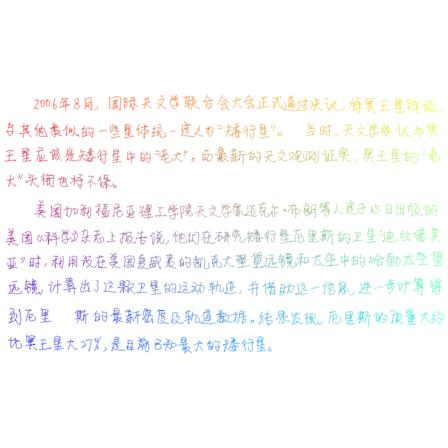
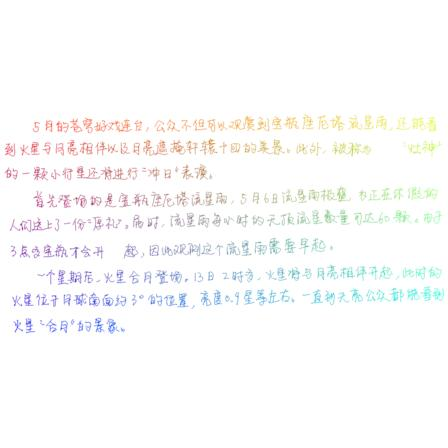
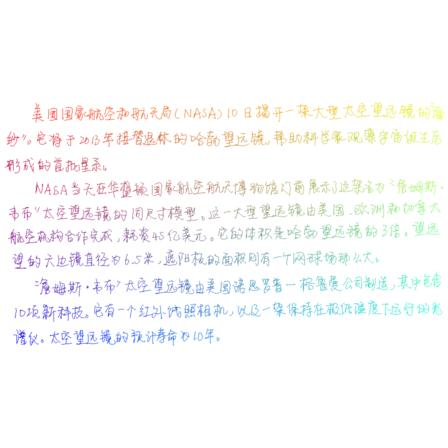

In [16]:
SEQLEN = 256

# --- 加载并测试数据集 ---

# 1. 定义数据路径
YOUR_IMAGE_DIR = "/kaggle/input/encoded-images/encoded_dataset/WPTT2.0-Test"
YOUR_JSONL_FILE_PATH = "/kaggle/working/WPTT2.0-Test.jsonl"

# 2. 使用 big_vision 加载数据源
try:
    your_custom_dataset = big_vision.datasets.jsonl.DataSource(
        YOUR_JSONL_FILE_PATH,
        fopen_keys={"image": YOUR_IMAGE_DIR}
    )
    print("成功加载自定义数据集。")
except Exception as e:
    print(f"加载自定义数据集时出错: {e}")
    print(f"请确保您已经运行了【第一步：将JSON转换为JSONL格式】的单元格，并且文件路径正确。")
    your_custom_dataset = None

# 3. 创建一个专门用于测试您数据的迭代器
def data_htr_test_iterator():
  """为自定义数据创建 htr 测试迭代器"""
  for example in your_custom_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = tf.image.decode_image(example["image"], channels=3).numpy()
    image = preprocess_image(image)
    #prefix = "handwriting recognition"
    prefix = "ocr" 
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)

    jax_batch_data = {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }
    ground_truth_text = example["suffix"].decode('utf-8')
    yield jax_batch_data, ground_truth_text

# 4. 调用预测函数并展示结果
if your_custom_dataset:
    print("--- 正在对图片进行HTR测试 ---")
    html_out_your_data = ""

    # 渲染函数
    def render_ocr_example(image, ground_truth, model_prediction):
      image = ((image + 1)/2 * 255).astype(np.uint8)
      return f"""
        <div style="display: flex; align-items: start; border: 1px solid #ccc; margin-bottom: 10px; padding: 5px;">
            <img style="width:128px; height:128px; margin-right: 10px;" src="{render_inline(image, resize=(128,128))}" />
            <div style="display: flex; flex-direction: column; max-width: 600px;">
                <p style="margin: 0; word-wrap: break-word;"><b>真实文本 (Ground Truth):</b><br>{html.escape(ground_truth)}</p>
                <hr style="width:100%; margin: 5px 0;">
                <p style="margin: 0; word-wrap: break-word;"><b>模型识别 (Prediction):</b><br>{html.escape(model_prediction)}</p>
            </div>
        </div>
        """

    iterator = your_data_ocr_test_iterator()
    # 测试您数据集中的前3张图片
    for _ in range(3):
        try:
            example_data, ground_truth_str = next(iterator)

            # 为 batch 添加 '_mask' 字段
            example_data['_mask'] = np.array(True)

            # 创建批次
            batch = jax.tree.map(lambda x: np.expand_dims(x, axis=0), example_data)
            batch = big_vision.utils.reshard(batch, data_sharding)

            # JAX处理和预测
            tokens = decode({"params": params}, batch=batch, max_decode_len=SEQLEN, sampler="greedy")

            tokens = jax.device_get(tokens)
            response = postprocess_tokens(tokens[0])

            html_out_your_data += render_ocr_example(example_data["image"], ground_truth_str, response)

        except StopIteration:
            print("已处理完所有可用的测试数据。")
            break

    display(HTML(html_out_your_data))

#### 构建**训练迭代器**并且对模型进行测试：

In [15]:
SEQLEN = 256

def train_data_iterator():
    """加载并合并所有自定义训练集，并创建迭代器。"""
    
    # 定义所有训练数据源
    source_2_0 = big_vision.datasets.jsonl.DataSource(
        '/kaggle/working/WPTT2.0-Train.jsonl',
        fopen_keys={'image': '/kaggle/input/encoded-images/encoded_dataset/WPTT2.0-Train'}
    )
    source_2_1 = big_vision.datasets.jsonl.DataSource(
        '/kaggle/working/WPTT2.1-Train.jsonl',
        fopen_keys={'image': '/kaggle/input/encoded-images/encoded_dataset/WPTT2.1-Train'}
    )
    source_2_2 = big_vision.datasets.jsonl.DataSource(
        '/kaggle/working/WPTT2.2-Train.jsonl',
        fopen_keys={'image': '/kaggle/input/encoded-images/encoded_dataset/WPTT2.2-Train'}
    )
    
    # 将多个数据源合并为一个 tf.data.Dataset 对象
    dataset_2_0 = source_2_0.get_tfdata()
    dataset_2_1 = source_2_1.get_tfdata()
    dataset_2_2 = source_2_2.get_tfdata()
    
    combined_dataset = dataset_2_0.concatenate(dataset_2_1).concatenate(dataset_2_2)
    
    # 对合并后的数据集进行随机打乱和无限重复
    dataset = combined_dataset.shuffle(1000).repeat()
    
    for example in dataset.as_numpy_iterator():
        # 图像解码和预处理
        image = tf.image.decode_image(example["image"], channels=3).numpy()
        image = preprocess_image(image) # 使用896px的预处理

        # 文本预处理，任务为 "ocr"，目标文本为 "suffix"
        prefix = "handwriting recognition"
        suffix = example["suffix"].decode('utf-8')
        tokens, mask_ar, mask_loss, _ = preprocess_tokens(prefix, suffix, SEQLEN)

        yield {
            "image": np.asarray(image),
            "text": np.asarray(tokens),
            "mask_ar": np.asarray(mask_ar),
            "mask_loss": np.asarray(mask_loss),
        }

print("训练数据迭代器 'train_data_iterator' 已定义。")


训练数据迭代器 'train_data_iterator' 已定义。


### 预处理所有训练集

 预处理所有训练集用于后续训练

 **以下代码框只需执行一次**

In [45]:
import json
import os

# --- JSON 到 JSONL 转换脚本 (修正版) ---

# 定义您的所有训练数据目录
train_dirs = [
    '/kaggle/input/encoded-images/encoded_dataset/WPTT2.0-Train',
    '/kaggle/input/encoded-images/encoded_dataset/WPTT2.1-Train',
    '/kaggle/input/encoded-images/encoded_dataset/WPTT2.2-Train'
]

# 输出路径（可写）
output_dir = '/kaggle/working/'
os.makedirs(output_dir, exist_ok=True)

# 循环处理每一个训练目录
for train_dir in train_dirs:
    try:
        # 修正点：将json文件名固定为 'metadata.json'
        json_file_name = 'metadata.json'
        json_file_path = os.path.join(train_dir, json_file_name)
        
        # 输出的 .jsonl 文件名仍然根据目录名来区分，方便管理
        dir_name = os.path.basename(train_dir)
        jsonl_file_name = f'{dir_name}.jsonl'
        jsonl_file_path = os.path.join(output_dir, jsonl_file_name)

        print(f"--- 开始处理目录: {dir_name} ---")
        print(f"正在读取JSON文件: {json_file_path}")

        # 读取原始的单个JSON对象
        with open(json_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 写入为JSONL格式
        with open(jsonl_file_path, 'w', encoding='utf-8') as f:
            for filename, text in data.items():
                text_cleaned = text.replace('\n', ' ')
                record = {"image": filename, "suffix": text_cleaned}
                f.write(json.dumps(record, ensure_ascii=False) + '\n')

        print(f"转换完成！文件已保存至: {jsonl_file_path}\n")

    except FileNotFoundError:
        print(f"错误：在目录 {train_dir} 中未找到文件 {json_file_name}。请确认文件名是否正确。")
    except Exception as e:
        print(f"处理目录 {train_dir} 时发生错误: {e}")

--- 开始处理目录: WPTT2.0-Train ---
正在读取JSON文件: /kaggle/input/encoded-images/encoded_dataset/WPTT2.0-Train/metadata.json
转换完成！文件已保存至: /kaggle/working/WPTT2.0-Train.jsonl

--- 开始处理目录: WPTT2.1-Train ---
正在读取JSON文件: /kaggle/input/encoded-images/encoded_dataset/WPTT2.1-Train/metadata.json
转换完成！文件已保存至: /kaggle/working/WPTT2.1-Train.jsonl

--- 开始处理目录: WPTT2.2-Train ---
正在读取JSON文件: /kaggle/input/encoded-images/encoded_dataset/WPTT2.2-Train/metadata.json
转换完成！文件已保存至: /kaggle/working/WPTT2.2-Train.jsonl



### 定义训练与评估循环

需要分别定义训练循环和评估循环：训练循环用于在给定数据集上训练模型，评估循环则用于遍历验证集并生成预测结果。

#### 定义训练循环

`update_fn` 函数用于实现训练步骤。在这个过程中，会为每个样本计算损失值，并对可训练参数应用随机梯度下降（SGD）进行优化。

还记得之前在 `preprocess_tokens` 函数中添加了 `mask_loss` 标记，用于标识哪些 token 应该参与损失计算。这里将用 `mask_loss` 排除前缀 token 和填充 token，避免干扰损失值的计算。同时，因为每个样本的 token 数量不同，还需要对损失值进行归一化处理。排除无效 token 并归一化后，才能准确计算每个样本的损失。

训练步骤最后会调用 SGD 优化器，对模型进行参数更新。

#### 定义评估循环

`make_predictions` 函数实现评估循环。



In [19]:
# 主更新函数，使用简单的随机梯度下降（SGD）
@functools.partial(jax.jit, donate_argnums=(0,))
def update_fn(params, batch, learning_rate):
  imgs, txts, mask_ar = batch["image"], batch["text"], batch["mask_ar"]

  def loss_fn(params):
    # 模型输入为 txts[:, :-1]，输出预测下一个 token 的 logits
    text_logits, _ = model.apply({"params": params}, imgs, txts[:, :-1], mask_ar[:, :-1], train=True)
    logp = jax.nn.log_softmax(text_logits, axis=-1)

    # 模型输入是 txts[:, :-1]，但损失计算目标是预测 txts[:, 1:]
    # mask_loss[:, 1:] 表示哪些 token 应该参与损失计算（如：不包括前缀和填充 token）
    mask_loss = batch["mask_loss"][:, 1:]
    targets = jax.nn.one_hot(txts[:, 1:], text_logits.shape[-1])

    # 计算每个样本的损失，即每个 token 的平均交叉熵损失
    # 因为每个样本的 token 数不同，所以需要做归一化处理
    token_pplx = jnp.sum(logp * targets, axis=-1)  # 在词汇表维度上求和
    example_loss = -jnp.sum(token_pplx * mask_loss, axis=-1)  # 在序列长度上求和
    example_loss /= jnp.clip(jnp.sum(mask_loss, -1), 1)  # 按实际 token 数归一化

    # 返回所有样本损失的平均值
    return jnp.mean(example_loss)

  loss, grads = jax.value_and_grad(loss_fn)(params)

  # 使用 SGD 将梯度应用到可训练参数
  def apply_grad(param, gradient, trainable):
    if not trainable: return param  # 若不可训练，直接返回
    return param - learning_rate * gradient  # 应用 SGD 更新

  # 遍历参数树进行梯度更新
  params = jax.tree_util.tree_map(apply_grad, params, grads, trainable_mask)

  return params, loss

# 评估 / 推理循环
def make_predictions(data_iterator, *, num_examples=None,
                     batch_size=4, seqlen=SEQLEN, sampler="greedy"):
  outputs = []
  while True:
    # 构造一个 batch 的样本列表
    examples = []
    try:
      for _ in range(batch_size):
        examples.append(next(data_iterator))
        examples[-1]["_mask"] = np.array(True)  # 标记为真实样本
    except StopIteration:
      if len(examples) == 0:
        return outputs  # 数据迭代完毕，返回结果

    # 若样本不足一个完整 batch，用最后一个样本填充
    while len(examples) % batch_size:
      examples.append(dict(examples[-1]))
      examples[-1]["_mask"] = np.array(False)  # 标记为填充样本

    # 将样本列表转换为 numpy 数组，并分发到设备上
    batch = jax.tree.map(lambda *x: np.stack(x), *examples)
    batch = big_vision.utils.reshard(batch, data_sharding)

    # 调用模型进行预测
    tokens = decode({"params": params}, batch=batch,
                    max_decode_len=seqlen, sampler=sampler)

    # 获取预测结果并去除填充样本
    tokens, mask = jax.device_get((tokens, batch["_mask"]))
    tokens = tokens[mask]  # 去除 padding 样本
    responses = [postprocess_tokens(t) for t in tokens]  # 解码 token

    # 将图像与预测结果组合输出
    for example, response in zip(examples, responses):
      outputs.append((example["image"], response))
      if num_examples and len(outputs) >= num_examples:
        return outputs  # 达到指定数量后提前结束


## 微调模型

现在一切准备就绪，开始正式微调模型。下面的代码将运行模型的训练循环，并在每一步打印学习率（输出中的 `lr`）和损失值。

每隔`EVAL_STEPS`步，模型会输出一次当前的预测结果。预测始终基于同一组图像，以便观察模型生成描述的能力在训练过程中的提升。

在训练的初期，模型生成的描述可能存在问题，比如句子重复（模型陷入预测循环）或语句不完整。但随着训练推进，模型的预测会逐步变得准确。训练完成后，模型的输出应该能较好地接近训练数据中提供的描述。

这里只采用了一半的训练集的数据进行训练，总图片数：3271

step:   1/1636   lr: 0.00012   loss: 1.4033
step:   2/1636   lr: 0.00024   loss: 1.6569
step:   3/1636   lr: 0.00037   loss: 2.4993
step:   4/1636   lr: 0.00049   loss: 1.6500
step:   5/1636   lr: 0.00061   loss: 1.7282
step:   6/1636   lr: 0.00073   loss: 2.0538
step:   7/1636   lr: 0.00085   loss: 2.1457
step:   8/1636   lr: 0.00098   loss: 1.2862
step:   9/1636   lr: 0.00110   loss: 0.6340
step:  10/1636   lr: 0.00122   loss: 1.2931
step:  11/1636   lr: 0.00134   loss: 1.4643
step:  12/1636   lr: 0.00146   loss: 3.7946
step:  13/1636   lr: 0.00159   loss: 3.6760
step:  14/1636   lr: 0.00171   loss: 3.5792
step:  15/1636   lr: 0.00183   loss: 2.6405
step:  16/1636   lr: 0.00195   loss: 2.9670
step:  17/1636   lr: 0.00207   loss: 2.9951
step:  18/1636   lr: 0.00220   loss: 3.0750
step:  19/1636   lr: 0.00232   loss: 3.3062
step:  20/1636   lr: 0.00244   loss: 3.3327
step:  21/1636   lr: 0.00256   loss: 3.4865
step:  22/1636   lr: 0.00268   loss: 3.3167
step:  23/1636   lr: 0.00280   l


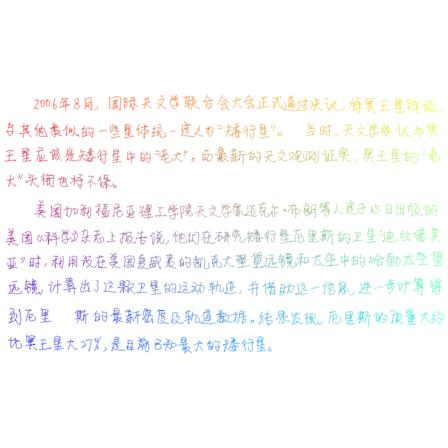
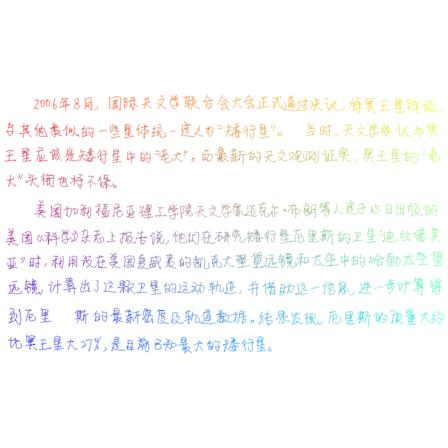

--------------------------------------------------
step:  51/1636   lr: 0.00622   loss: 2.8565
step:  52/1636   lr: 0.00634   loss: 1.6936
step:  53/1636   lr: 0.00646   loss: 1.6138
step:  54/1636   lr: 0.00659   loss: 2.7253
step:  55/1636   lr: 0.00671   loss: 4.3949
step:  56/1636   lr: 0.00683   loss: 3.3438
step:  57/1636   lr: 0.00695   loss: 1.8306
step:  58/1636   lr: 0.00707   loss: 2.8126
step:  59/1636   lr: 0.00720   loss: 2.8587
step:  60/1636   lr: 0.00732   loss: 1.9473
step:  61/1636   lr: 0.00744   loss: 1.8424
step:  62/1636   lr: 0.00756   loss: 2.6147
step:  63/1636   lr: 0.00768   loss: 2.8817
step:  64/1636   lr: 0.00780   loss: 2.3938
step:  65/1636   lr: 0.00793   loss: 2.1614
step:  66/1636   lr: 0.00805   loss: 2.1478
step:  67/1636   lr: 0.00817   loss: 2.4220
step:  68/1636   lr: 0.00829   loss: 1.6349
step:  69/1636   lr: 0.00841   loss: 2.2387
step:  70/1636   lr: 0.00854   loss: 2.1210
step:  71/1636   lr: 0.00866   loss: 1.6843
step:  72/1636   lr: 0.00


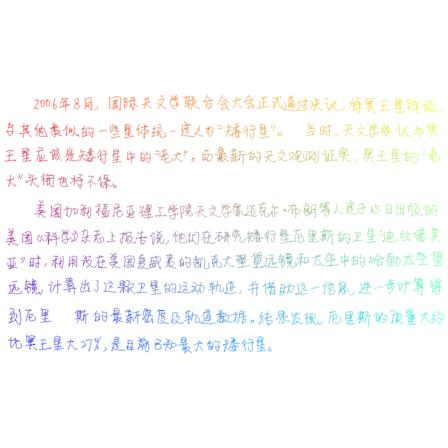
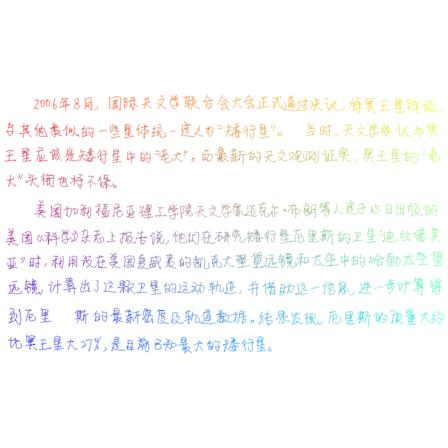

--------------------------------------------------
step: 101/1636   lr: 0.01232   loss: 2.3050
step: 102/1636   lr: 0.01244   loss: 1.4661
step: 103/1636   lr: 0.01256   loss: 2.0266
step: 104/1636   lr: 0.01268   loss: 2.3982
step: 105/1636   lr: 0.01280   loss: 2.0183
step: 106/1636   lr: 0.01293   loss: 2.0268
step: 107/1636   lr: 0.01305   loss: 2.2407
step: 108/1636   lr: 0.01317   loss: 1.6940
step: 109/1636   lr: 0.01329   loss: 3.8262
step: 110/1636   lr: 0.01341   loss: 3.1923
step: 111/1636   lr: 0.01354   loss: 3.0183
step: 112/1636   lr: 0.01366   loss: 1.9649
step: 113/1636   lr: 0.01378   loss: 2.2365
step: 114/1636   lr: 0.01390   loss: 1.9845
step: 115/1636   lr: 0.01402   loss: 1.5505
step: 116/1636   lr: 0.01415   loss: 1.2232
step: 117/1636   lr: 0.01427   loss: 0.6653
step: 118/1636   lr: 0.01439   loss: 1.7524
step: 119/1636   lr: 0.01451   loss: 1.4380
step: 120/1636   lr: 0.01463   loss: 1.4103
step: 121/1636   lr: 0.01476   loss: 1.6948
step: 122/1636   lr: 0.01


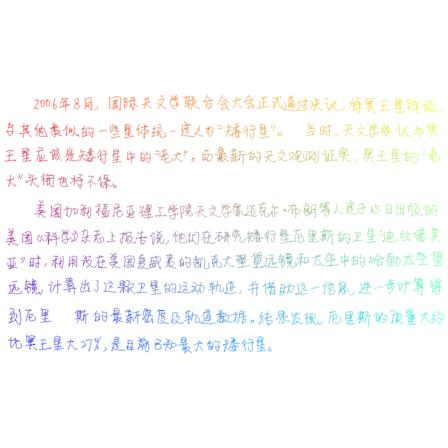
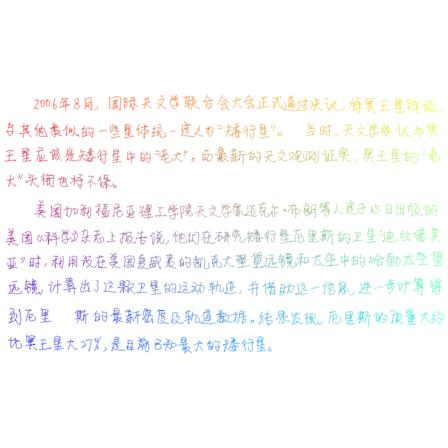

--------------------------------------------------
step: 151/1636   lr: 0.01841   loss: 0.9592
step: 152/1636   lr: 0.01854   loss: 1.0251
step: 153/1636   lr: 0.01866   loss: 1.4616
step: 154/1636   lr: 0.01878   loss: 1.7336
step: 155/1636   lr: 0.01890   loss: 1.0516
step: 156/1636   lr: 0.01902   loss: 0.6752
step: 157/1636   lr: 0.01915   loss: 1.0976
step: 158/1636   lr: 0.01927   loss: 1.4129
step: 159/1636   lr: 0.01939   loss: 1.4562
step: 160/1636   lr: 0.01951   loss: 0.9531
step: 161/1636   lr: 0.01963   loss: 0.8731
step: 162/1636   lr: 0.01976   loss: 2.0365
step: 163/1636   lr: 0.01988   loss: 2.1878
step: 164/1636   lr: 0.02000   loss: 1.3815
step: 165/1636   lr: 0.02000   loss: 2.4091
step: 166/1636   lr: 0.02000   loss: 1.0178
step: 167/1636   lr: 0.02000   loss: 1.0578
step: 168/1636   lr: 0.02000   loss: 2.6394
step: 169/1636   lr: 0.02000   loss: 1.8767
step: 170/1636   lr: 0.02000   loss: 0.8878
step: 171/1636   lr: 0.02000   loss: 3.9093
step: 172/1636   lr: 0.02


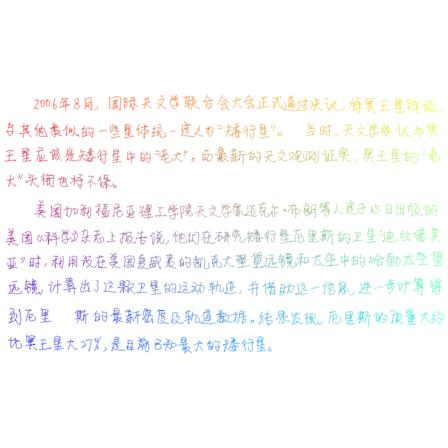
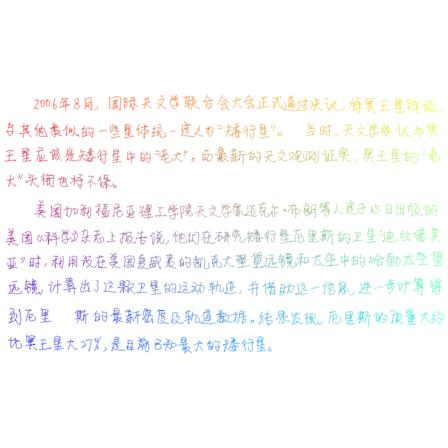

--------------------------------------------------
step: 201/1636   lr: 0.01997   loss: 0.3845
step: 202/1636   lr: 0.01997   loss: 0.6956
step: 203/1636   lr: 0.01997   loss: 0.3252
step: 204/1636   lr: 0.01996   loss: 1.0087
step: 205/1636   lr: 0.01996   loss: 0.8415
step: 206/1636   lr: 0.01996   loss: 0.4910
step: 207/1636   lr: 0.01996   loss: 0.7732
step: 208/1636   lr: 0.01996   loss: 0.7739
step: 209/1636   lr: 0.01995   loss: 1.2423
step: 210/1636   lr: 0.01995   loss: 0.3381
step: 211/1636   lr: 0.01995   loss: 0.4777
step: 212/1636   lr: 0.01995   loss: 0.4137
step: 213/1636   lr: 0.01995   loss: 0.9114
step: 214/1636   lr: 0.01994   loss: 0.4452
step: 215/1636   lr: 0.01994   loss: 0.7055
step: 216/1636   lr: 0.01994   loss: 0.4903
step: 217/1636   lr: 0.01994   loss: 0.9142
step: 218/1636   lr: 0.01993   loss: 0.3409
step: 219/1636   lr: 0.01993   loss: 1.0280
step: 220/1636   lr: 0.01993   loss: 0.4018
step: 221/1636   lr: 0.01993   loss: 0.7773
step: 222/1636   lr: 0.01


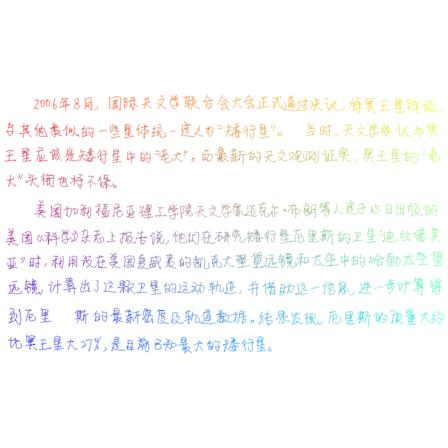
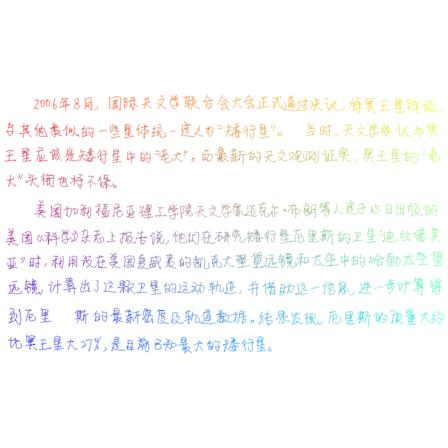

--------------------------------------------------
step: 251/1636   lr: 0.01983   loss: 0.6386
step: 252/1636   lr: 0.01982   loss: 1.3478
step: 253/1636   lr: 0.01982   loss: 0.5782
step: 254/1636   lr: 0.01982   loss: 0.2187
step: 255/1636   lr: 0.01981   loss: 0.3290
step: 256/1636   lr: 0.01981   loss: 0.1003
step: 257/1636   lr: 0.01980   loss: 0.8547
step: 258/1636   lr: 0.01980   loss: 0.2385
step: 259/1636   lr: 0.01980   loss: 0.4296
step: 260/1636   lr: 0.01979   loss: 0.4355
step: 261/1636   lr: 0.01979   loss: 0.8759
step: 262/1636   lr: 0.01978   loss: 0.2091
step: 263/1636   lr: 0.01978   loss: 0.2216
step: 264/1636   lr: 0.01977   loss: 0.3984
step: 265/1636   lr: 0.01977   loss: 0.4630
step: 266/1636   lr: 0.01976   loss: 0.3034
step: 267/1636   lr: 0.01976   loss: 0.8097
step: 268/1636   lr: 0.01976   loss: 0.3487
step: 269/1636   lr: 0.01975   loss: 0.7353
step: 270/1636   lr: 0.01975   loss: 0.4668
step: 271/1636   lr: 0.01974   loss: 0.3204
step: 272/1636   lr: 0.01


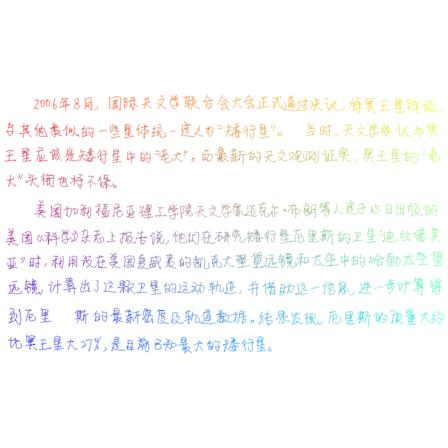
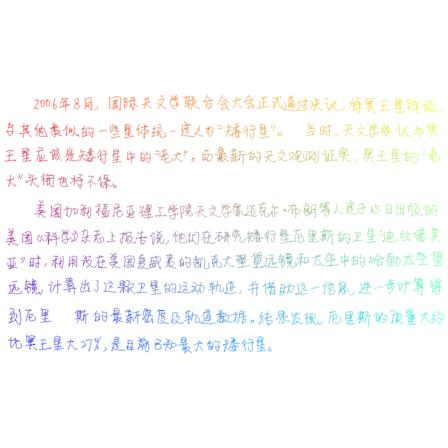

--------------------------------------------------
step: 301/1636   lr: 0.01958   loss: 0.1250
step: 302/1636   lr: 0.01957   loss: 0.2344
step: 303/1636   lr: 0.01956   loss: 0.3023
step: 304/1636   lr: 0.01956   loss: 0.2276
step: 305/1636   lr: 0.01955   loss: 0.4454
step: 306/1636   lr: 0.01954   loss: 0.1673
step: 307/1636   lr: 0.01954   loss: 0.2219
step: 308/1636   lr: 0.01953   loss: 0.1775
step: 309/1636   lr: 0.01953   loss: 0.4582
step: 310/1636   lr: 0.01952   loss: 0.4406
step: 311/1636   lr: 0.01951   loss: 0.3550
step: 312/1636   lr: 0.01951   loss: 0.3056
step: 313/1636   lr: 0.01950   loss: 0.9548
step: 314/1636   lr: 0.01949   loss: 0.3195
step: 315/1636   lr: 0.01949   loss: 0.5360
step: 316/1636   lr: 0.01948   loss: 0.3159
step: 317/1636   lr: 0.01947   loss: 0.0836
step: 318/1636   lr: 0.01947   loss: 0.0944
step: 319/1636   lr: 0.01946   loss: 0.5906
step: 320/1636   lr: 0.01945   loss: 0.4033
step: 321/1636   lr: 0.01944   loss: 0.2582
step: 322/1636   lr: 0.01


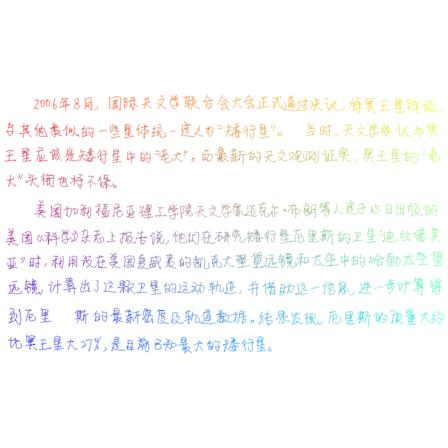
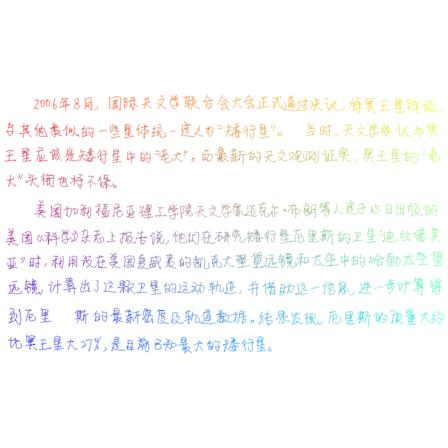

--------------------------------------------------
step: 351/1636   lr: 0.01922   loss: 0.2690
step: 352/1636   lr: 0.01921   loss: 0.2989
step: 353/1636   lr: 0.01920   loss: 0.7042
step: 354/1636   lr: 0.01919   loss: 0.4820
step: 355/1636   lr: 0.01918   loss: 0.1621
step: 356/1636   lr: 0.01917   loss: 0.3377
step: 357/1636   lr: 0.01916   loss: 0.2644
step: 358/1636   lr: 0.01916   loss: 0.2748
step: 359/1636   lr: 0.01915   loss: 0.2080
step: 360/1636   lr: 0.01914   loss: 0.2061
step: 361/1636   lr: 0.01913   loss: 0.2692
step: 362/1636   lr: 0.01912   loss: 0.0698
step: 363/1636   lr: 0.01911   loss: 0.3557
step: 364/1636   lr: 0.01910   loss: 0.1584
step: 365/1636   lr: 0.01910   loss: 0.7653
step: 366/1636   lr: 0.01909   loss: 0.2424
step: 367/1636   lr: 0.01908   loss: 0.0514
step: 368/1636   lr: 0.01907   loss: 0.1825
step: 369/1636   lr: 0.01906   loss: 0.1055
step: 370/1636   lr: 0.01905   loss: 0.0797
step: 371/1636   lr: 0.01904   loss: 0.2123
step: 372/1636   lr: 0.01


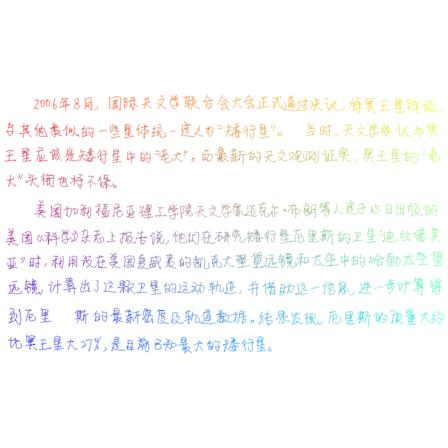
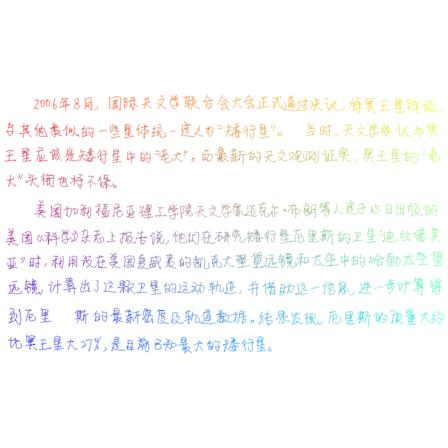

--------------------------------------------------
step: 401/1636   lr: 0.01875   loss: 0.1687
step: 402/1636   lr: 0.01874   loss: 0.1321
step: 403/1636   lr: 0.01873   loss: 0.2933
step: 404/1636   lr: 0.01872   loss: 0.2270
step: 405/1636   lr: 0.01871   loss: 0.0358
step: 406/1636   lr: 0.01870   loss: 0.1255
step: 407/1636   lr: 0.01869   loss: 0.0136
step: 408/1636   lr: 0.01868   loss: 0.7358
step: 409/1636   lr: 0.01867   loss: 0.5193
step: 410/1636   lr: 0.01865   loss: 0.4097
step: 411/1636   lr: 0.01864   loss: 0.4291
step: 412/1636   lr: 0.01863   loss: 0.4532
step: 413/1636   lr: 0.01862   loss: 0.0396
step: 414/1636   lr: 0.01861   loss: 0.0626
step: 415/1636   lr: 0.01860   loss: 0.0491
step: 416/1636   lr: 0.01859   loss: 0.1172
step: 417/1636   lr: 0.01858   loss: 0.0163
step: 418/1636   lr: 0.01857   loss: 0.1667
step: 419/1636   lr: 0.01856   loss: 0.2733
step: 420/1636   lr: 0.01855   loss: 0.1347
step: 421/1636   lr: 0.01854   loss: 0.7205
step: 422/1636   lr: 0.01


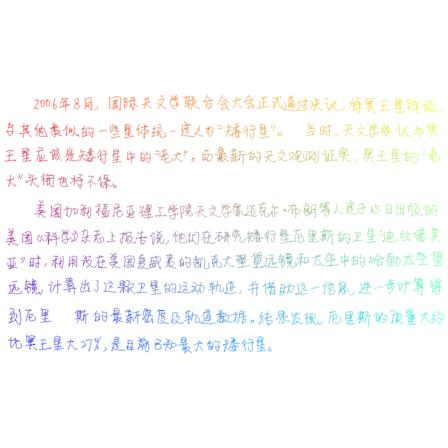
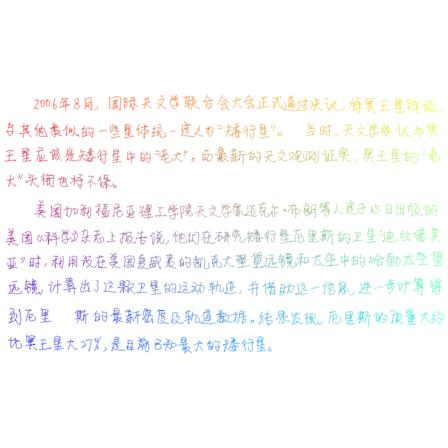

--------------------------------------------------
step: 451/1636   lr: 0.01818   loss: 0.2488
step: 452/1636   lr: 0.01817   loss: 0.2371
step: 453/1636   lr: 0.01816   loss: 0.2014
step: 454/1636   lr: 0.01815   loss: 0.2712
step: 455/1636   lr: 0.01814   loss: 0.2123
step: 456/1636   lr: 0.01812   loss: 0.4058
step: 457/1636   lr: 0.01811   loss: 0.1479
step: 458/1636   lr: 0.01810   loss: 0.1140
step: 459/1636   lr: 0.01809   loss: 0.1189
step: 460/1636   lr: 0.01807   loss: 0.1355
step: 461/1636   lr: 0.01806   loss: 0.0686
step: 462/1636   lr: 0.01805   loss: 0.1071
step: 463/1636   lr: 0.01803   loss: 0.1427
step: 464/1636   lr: 0.01802   loss: 0.2219
step: 465/1636   lr: 0.01801   loss: 0.8226
step: 466/1636   lr: 0.01800   loss: 0.0652
step: 467/1636   lr: 0.01798   loss: 0.5318
step: 468/1636   lr: 0.01797   loss: 0.0516
step: 469/1636   lr: 0.01796   loss: 0.2463
step: 470/1636   lr: 0.01794   loss: 0.2208
step: 471/1636   lr: 0.01793   loss: 0.0759
step: 472/1636   lr: 0.01


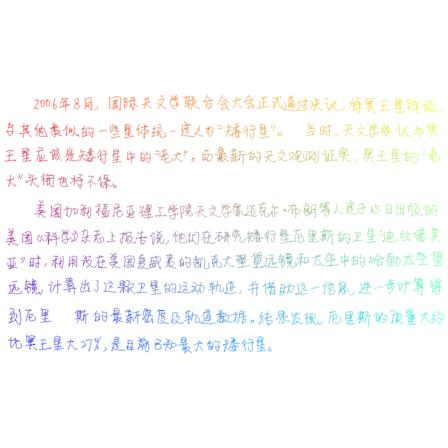
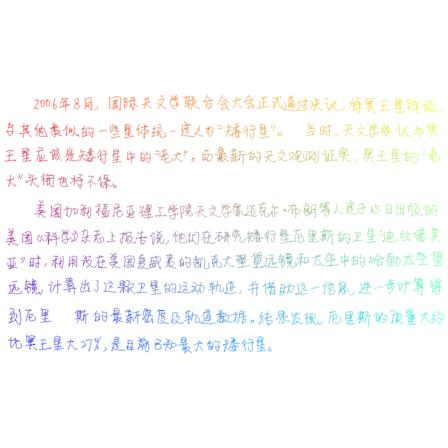

--------------------------------------------------
step: 501/1636   lr: 0.01753   loss: 0.2421
step: 502/1636   lr: 0.01751   loss: 0.1454
step: 503/1636   lr: 0.01750   loss: 0.0763
step: 504/1636   lr: 0.01748   loss: 0.1277
step: 505/1636   lr: 0.01747   loss: 0.1771
step: 506/1636   lr: 0.01746   loss: 0.1011
step: 507/1636   lr: 0.01744   loss: 0.9173
step: 508/1636   lr: 0.01743   loss: 0.3143
step: 509/1636   lr: 0.01741   loss: 0.0847
step: 510/1636   lr: 0.01740   loss: 0.5090
step: 511/1636   lr: 0.01738   loss: 0.3066
step: 512/1636   lr: 0.01737   loss: 0.2386
step: 513/1636   lr: 0.01736   loss: 0.1385
step: 514/1636   lr: 0.01734   loss: 0.0862
step: 515/1636   lr: 0.01733   loss: 0.1204
step: 516/1636   lr: 0.01731   loss: 0.4550
step: 517/1636   lr: 0.01730   loss: 0.1450
step: 518/1636   lr: 0.01728   loss: 0.0776
step: 519/1636   lr: 0.01727   loss: 0.2979
step: 520/1636   lr: 0.01725   loss: 0.1117
step: 521/1636   lr: 0.01724   loss: 0.3093
step: 522/1636   lr: 0.01


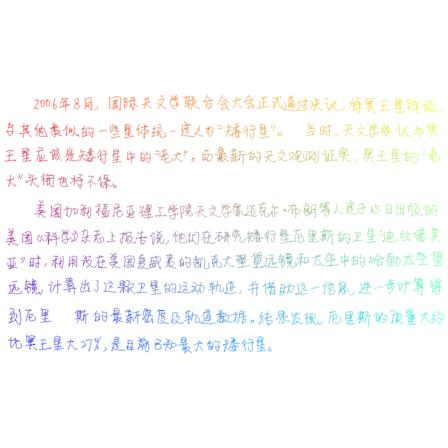
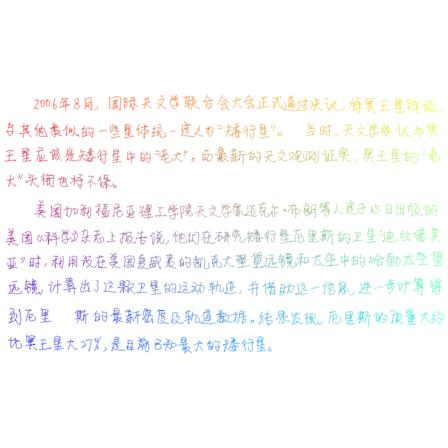

--------------------------------------------------
step: 551/1636   lr: 0.01678   loss: 0.1226
step: 552/1636   lr: 0.01677   loss: 0.0091
step: 553/1636   lr: 0.01675   loss: 0.1401
step: 554/1636   lr: 0.01674   loss: 0.0746
step: 555/1636   lr: 0.01672   loss: 0.1269
step: 556/1636   lr: 0.01670   loss: 0.0632
step: 557/1636   lr: 0.01669   loss: 0.0571
step: 558/1636   lr: 0.01667   loss: 0.1661
step: 559/1636   lr: 0.01666   loss: 0.1865
step: 560/1636   lr: 0.01664   loss: 0.0548
step: 561/1636   lr: 0.01662   loss: 0.1046
step: 562/1636   lr: 0.01661   loss: 0.0341
step: 563/1636   lr: 0.01659   loss: 0.0397
step: 564/1636   lr: 0.01658   loss: 0.2214
step: 565/1636   lr: 0.01656   loss: 0.0865
step: 566/1636   lr: 0.01654   loss: 0.2625
step: 567/1636   lr: 0.01653   loss: 0.1966
step: 568/1636   lr: 0.01651   loss: 0.0588
step: 569/1636   lr: 0.01650   loss: 0.2151
step: 570/1636   lr: 0.01648   loss: 0.1478
step: 571/1636   lr: 0.01646   loss: 0.1406
step: 572/1636   lr: 0.01


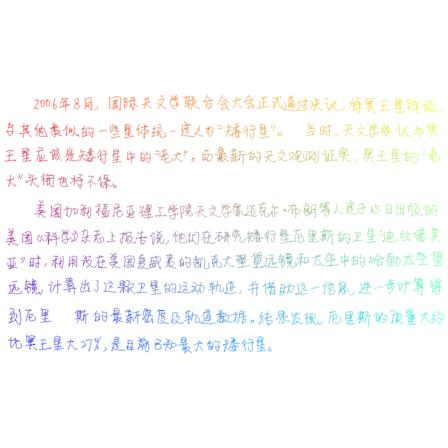
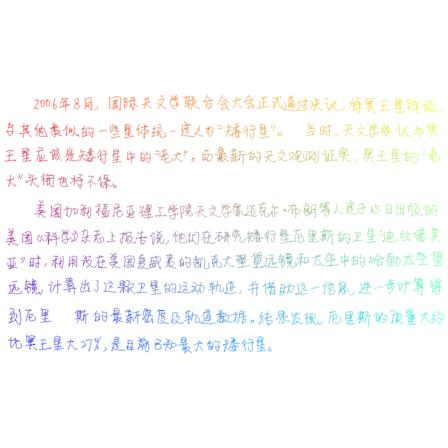

--------------------------------------------------
step: 601/1636   lr: 0.01596   loss: 0.1156
step: 602/1636   lr: 0.01594   loss: 0.0431
step: 603/1636   lr: 0.01593   loss: 0.0876
step: 604/1636   lr: 0.01591   loss: 0.1434
step: 605/1636   lr: 0.01589   loss: 0.2666
step: 606/1636   lr: 0.01588   loss: 0.1962
step: 607/1636   lr: 0.01586   loss: 0.1161
step: 608/1636   lr: 0.01584   loss: 0.0235
step: 609/1636   lr: 0.01582   loss: 0.1398
step: 610/1636   lr: 0.01581   loss: 0.0388
step: 611/1636   lr: 0.01579   loss: 0.4734
step: 612/1636   lr: 0.01577   loss: 0.0742
step: 613/1636   lr: 0.01575   loss: 0.1088
step: 614/1636   lr: 0.01574   loss: 0.0140
step: 615/1636   lr: 0.01572   loss: 0.7817
step: 616/1636   lr: 0.01570   loss: 0.2843
step: 617/1636   lr: 0.01568   loss: 0.1565
step: 618/1636   lr: 0.01567   loss: 0.1424
step: 619/1636   lr: 0.01565   loss: 0.1249
step: 620/1636   lr: 0.01563   loss: 0.0643
step: 621/1636   lr: 0.01561   loss: 0.3197
step: 622/1636   lr: 0.01


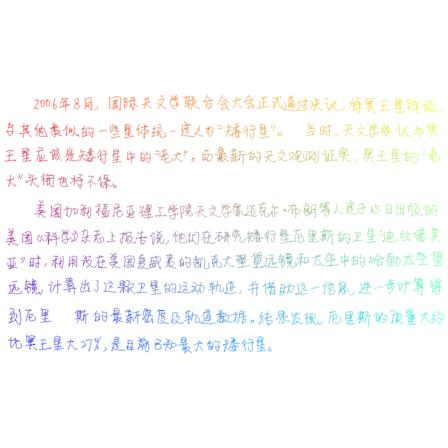
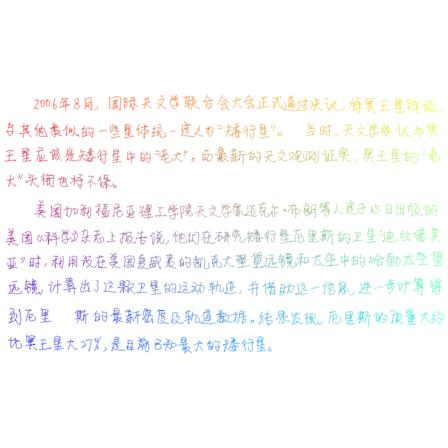

--------------------------------------------------
step: 651/1636   lr: 0.01507   loss: 0.0181
step: 652/1636   lr: 0.01506   loss: 0.0704
step: 653/1636   lr: 0.01504   loss: 0.0614
step: 654/1636   lr: 0.01502   loss: 0.0144
step: 655/1636   lr: 0.01500   loss: 0.1345
step: 656/1636   lr: 0.01498   loss: 0.0863
step: 657/1636   lr: 0.01496   loss: 0.0531
step: 658/1636   lr: 0.01494   loss: 0.0091
step: 659/1636   lr: 0.01493   loss: 0.0199
step: 660/1636   lr: 0.01491   loss: 0.0232
step: 661/1636   lr: 0.01489   loss: 0.0793
step: 662/1636   lr: 0.01487   loss: 0.1651
step: 663/1636   lr: 0.01485   loss: 0.0051
step: 664/1636   lr: 0.01483   loss: 0.0349
step: 665/1636   lr: 0.01481   loss: 0.2354
step: 666/1636   lr: 0.01480   loss: 0.1416
step: 667/1636   lr: 0.01478   loss: 0.1709
step: 668/1636   lr: 0.01476   loss: 0.3485
step: 669/1636   lr: 0.01474   loss: 0.0508
step: 670/1636   lr: 0.01472   loss: 0.2483
step: 671/1636   lr: 0.01470   loss: 0.2068
step: 672/1636   lr: 0.01


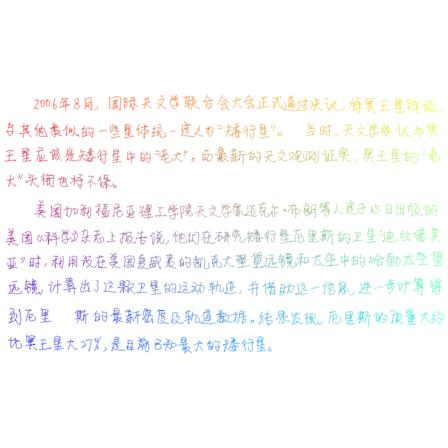
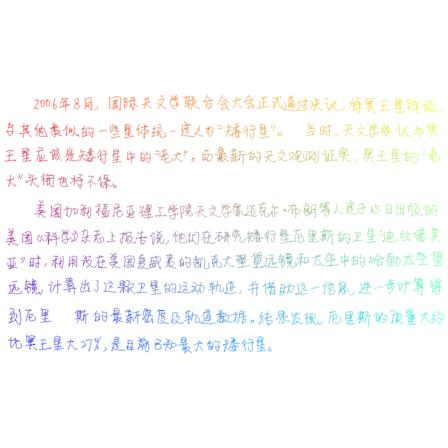

--------------------------------------------------
step: 701/1636   lr: 0.01413   loss: 0.2725
step: 702/1636   lr: 0.01411   loss: 0.0305
step: 703/1636   lr: 0.01409   loss: 0.2064
step: 704/1636   lr: 0.01407   loss: 0.2625
step: 705/1636   lr: 0.01405   loss: 0.1531
step: 706/1636   lr: 0.01403   loss: 0.2214
step: 707/1636   lr: 0.01401   loss: 0.2959
step: 708/1636   lr: 0.01399   loss: 0.1596
step: 709/1636   lr: 0.01397   loss: 0.0490
step: 710/1636   lr: 0.01395   loss: 0.1591
step: 711/1636   lr: 0.01393   loss: 0.1069
step: 712/1636   lr: 0.01391   loss: 0.0528
step: 713/1636   lr: 0.01389   loss: 0.0576
step: 714/1636   lr: 0.01387   loss: 0.0721
step: 715/1636   lr: 0.01385   loss: 0.0092
step: 716/1636   lr: 0.01383   loss: 0.0074
step: 717/1636   lr: 0.01381   loss: 0.3226
step: 718/1636   lr: 0.01379   loss: 0.0639
step: 719/1636   lr: 0.01378   loss: 0.1522
step: 720/1636   lr: 0.01376   loss: 0.0329
step: 721/1636   lr: 0.01374   loss: 0.0233
step: 722/1636   lr: 0.01


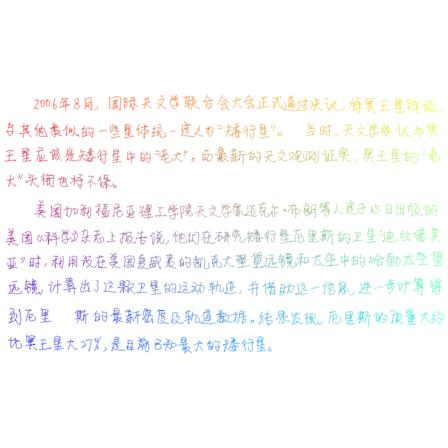
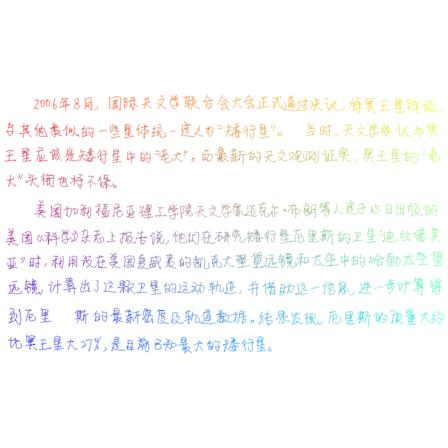

--------------------------------------------------
step: 751/1636   lr: 0.01313   loss: 0.6669
step: 752/1636   lr: 0.01311   loss: 0.2435
step: 753/1636   lr: 0.01309   loss: 0.3602
step: 754/1636   lr: 0.01307   loss: 0.2503
step: 755/1636   lr: 0.01305   loss: 4.7917
step: 756/1636   lr: 0.01303   loss: 0.2794
step: 757/1636   lr: 0.01301   loss: 2.8074
step: 758/1636   lr: 0.01299   loss: 0.3688
step: 759/1636   lr: 0.01297   loss: 0.0607
step: 760/1636   lr: 0.01295   loss: 0.2018
step: 761/1636   lr: 0.01293   loss: 0.2557
step: 762/1636   lr: 0.01291   loss: 0.2595
step: 763/1636   lr: 0.01289   loss: 0.0461
step: 764/1636   lr: 0.01287   loss: 0.0511
step: 765/1636   lr: 0.01285   loss: 0.1087
step: 766/1636   lr: 0.01283   loss: 0.0737
step: 767/1636   lr: 0.01281   loss: 0.0211
step: 768/1636   lr: 0.01279   loss: 0.0149
step: 769/1636   lr: 0.01277   loss: 0.3860
step: 770/1636   lr: 0.01275   loss: 0.0802
step: 771/1636   lr: 0.01273   loss: 0.2689
step: 772/1636   lr: 0.01


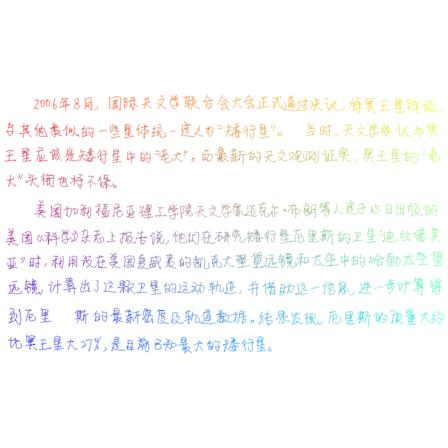
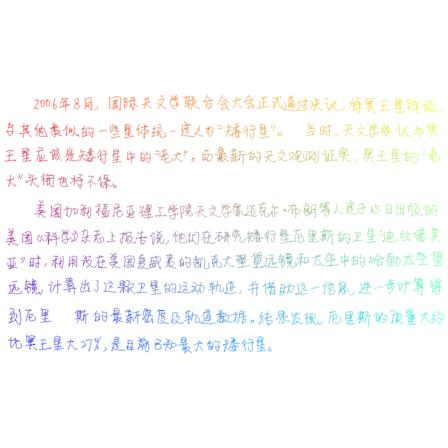

--------------------------------------------------
step: 801/1636   lr: 0.01211   loss: 0.1470
step: 802/1636   lr: 0.01209   loss: 0.0629
step: 803/1636   lr: 0.01206   loss: 0.2275
step: 804/1636   lr: 0.01204   loss: 0.0286
step: 805/1636   lr: 0.01202   loss: 0.0224
step: 806/1636   lr: 0.01200   loss: 0.3658
step: 807/1636   lr: 0.01198   loss: 0.1823
step: 808/1636   lr: 0.01196   loss: 0.0143
step: 809/1636   lr: 0.01194   loss: 0.0692
step: 810/1636   lr: 0.01192   loss: 0.0451
step: 811/1636   lr: 0.01190   loss: 0.1024
step: 812/1636   lr: 0.01188   loss: 3.2975
step: 813/1636   lr: 0.01186   loss: 0.1347
step: 814/1636   lr: 0.01183   loss: 0.1308
step: 815/1636   lr: 0.01181   loss: 0.0293
step: 816/1636   lr: 0.01179   loss: 0.0501
step: 817/1636   lr: 0.01177   loss: 0.4516
step: 818/1636   lr: 0.01175   loss: 0.2083
step: 819/1636   lr: 0.01173   loss: 0.3484
step: 820/1636   lr: 0.01171   loss: 0.0307
step: 821/1636   lr: 0.01169   loss: 1.1809
step: 822/1636   lr: 0.01


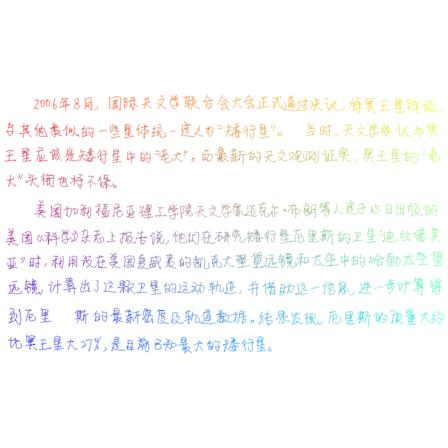
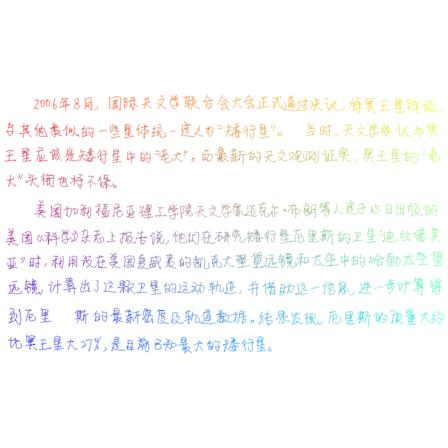

--------------------------------------------------
step: 851/1636   lr: 0.01105   loss: 0.0270
step: 852/1636   lr: 0.01103   loss: 0.0719
step: 853/1636   lr: 0.01101   loss: 0.1052
step: 854/1636   lr: 0.01099   loss: 0.1221
step: 855/1636   lr: 0.01097   loss: 0.0950
step: 856/1636   lr: 0.01095   loss: 0.0473
step: 857/1636   lr: 0.01093   loss: 2.4480
step: 858/1636   lr: 0.01091   loss: 0.0254
step: 859/1636   lr: 0.01088   loss: 0.0418
step: 860/1636   lr: 0.01086   loss: 0.0350
step: 861/1636   lr: 0.01084   loss: 0.1344
step: 862/1636   lr: 0.01082   loss: 0.3017
step: 863/1636   lr: 0.01080   loss: 0.0486
step: 864/1636   lr: 0.01078   loss: 0.1307
step: 865/1636   lr: 0.01076   loss: 0.0959
step: 866/1636   lr: 0.01074   loss: 2.6296
step: 867/1636   lr: 0.01071   loss: 0.1735
step: 868/1636   lr: 0.01069   loss: 0.0181
step: 869/1636   lr: 0.01067   loss: 0.2177
step: 870/1636   lr: 0.01065   loss: 0.0512
step: 871/1636   lr: 0.01063   loss: 0.0995
step: 872/1636   lr: 0.01


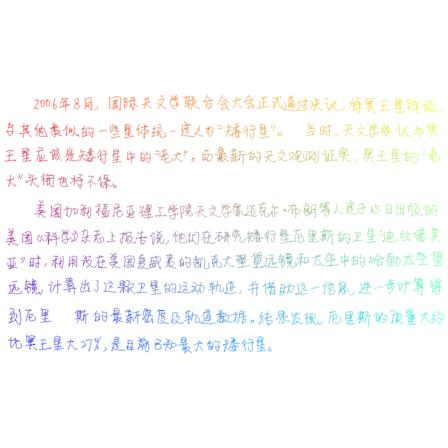
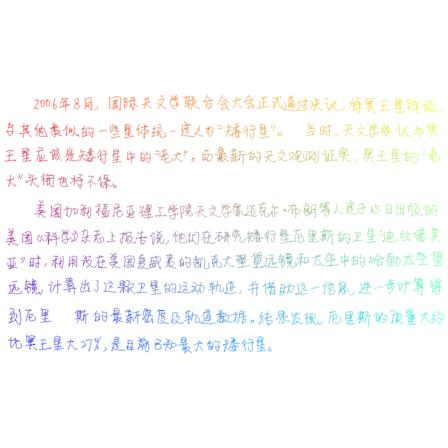

--------------------------------------------------
step: 901/1636   lr: 0.00999   loss: 0.1399
step: 902/1636   lr: 0.00997   loss: 0.0575
step: 903/1636   lr: 0.00995   loss: 2.3667
step: 904/1636   lr: 0.00993   loss: 0.1268
step: 905/1636   lr: 0.00990   loss: 0.0076
step: 906/1636   lr: 0.00988   loss: 0.3162
step: 907/1636   lr: 0.00986   loss: 0.0277
step: 908/1636   lr: 0.00984   loss: 0.0719
step: 909/1636   lr: 0.00982   loss: 0.0894
step: 910/1636   lr: 0.00980   loss: 2.4450
step: 911/1636   lr: 0.00978   loss: 0.4772
step: 912/1636   lr: 0.00975   loss: 0.1204
step: 913/1636   lr: 0.00973   loss: 0.1766
step: 914/1636   lr: 0.00971   loss: 0.1414
step: 915/1636   lr: 0.00969   loss: 1.8675
step: 916/1636   lr: 0.00967   loss: 0.0784
step: 917/1636   lr: 0.00965   loss: 0.1203
step: 918/1636   lr: 0.00963   loss: 0.0408
step: 919/1636   lr: 0.00961   loss: 0.0908
step: 920/1636   lr: 0.00958   loss: 0.0096
step: 921/1636   lr: 0.00956   loss: 0.0614
step: 922/1636   lr: 0.00


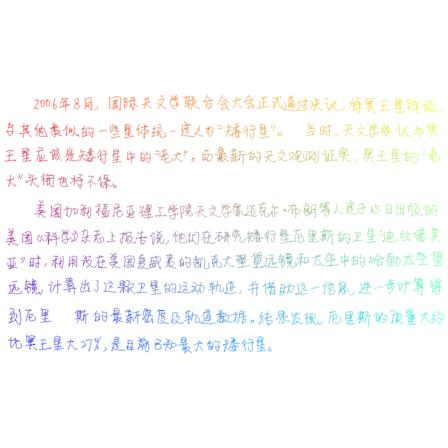
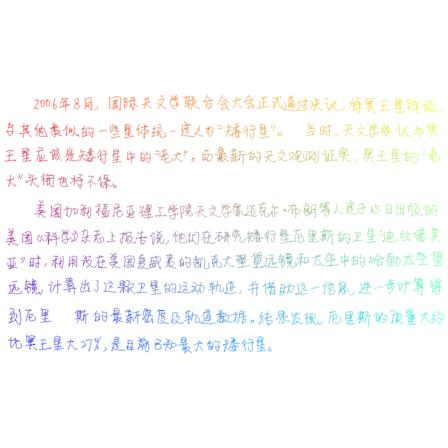

--------------------------------------------------
step: 951/1636   lr: 0.00893   loss: 0.1008
step: 952/1636   lr: 0.00890   loss: 0.1421
step: 953/1636   lr: 0.00888   loss: 0.1507
step: 954/1636   lr: 0.00886   loss: 0.2932
step: 955/1636   lr: 0.00884   loss: 2.7899
step: 956/1636   lr: 0.00882   loss: 0.1008
step: 957/1636   lr: 0.00880   loss: 0.1483
step: 958/1636   lr: 0.00878   loss: 0.1226
step: 959/1636   lr: 0.00876   loss: 0.0274
step: 960/1636   lr: 0.00873   loss: 1.3522
step: 961/1636   lr: 0.00871   loss: 0.0848
step: 962/1636   lr: 0.00869   loss: 2.7958
step: 963/1636   lr: 0.00867   loss: 0.0482
step: 964/1636   lr: 0.00865   loss: 0.1379
step: 965/1636   lr: 0.00863   loss: 1.4238
step: 966/1636   lr: 0.00861   loss: 0.1721
step: 967/1636   lr: 0.00859   loss: 0.0559
step: 968/1636   lr: 0.00857   loss: 0.2217
step: 969/1636   lr: 0.00854   loss: 0.0474
step: 970/1636   lr: 0.00852   loss: 0.1599
step: 971/1636   lr: 0.00850   loss: 1.8722
step: 972/1636   lr: 0.00


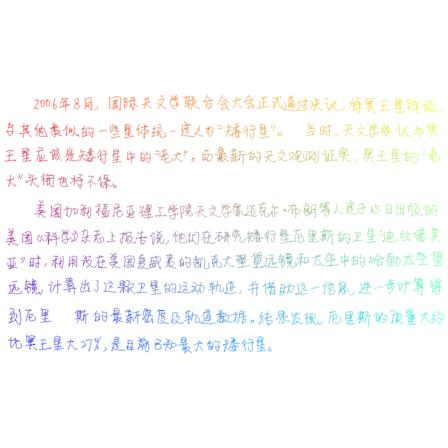
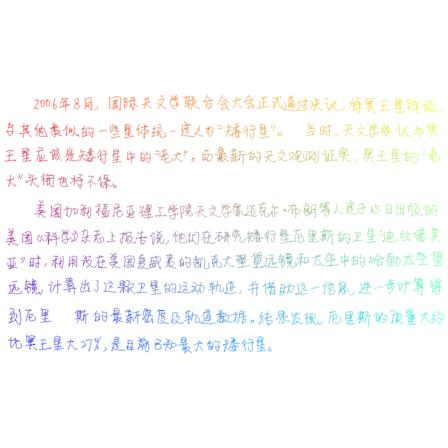

--------------------------------------------------
step: 1001/1636   lr: 0.00787   loss: 0.3036
step: 1002/1636   lr: 0.00785   loss: 0.0585
step: 1003/1636   lr: 0.00783   loss: 0.0487
step: 1004/1636   lr: 0.00781   loss: 0.2325
step: 1005/1636   lr: 0.00779   loss: 0.0734
step: 1006/1636   lr: 0.00777   loss: 0.0950
step: 1007/1636   lr: 0.00775   loss: 1.0373
step: 1008/1636   lr: 0.00773   loss: 0.0610
step: 1009/1636   lr: 0.00771   loss: 0.2082
step: 1010/1636   lr: 0.00769   loss: 0.1477
step: 1011/1636   lr: 0.00767   loss: 0.0364
step: 1012/1636   lr: 0.00764   loss: 0.1363
step: 1013/1636   lr: 0.00762   loss: 0.1454
step: 1014/1636   lr: 0.00760   loss: 0.1292
step: 1015/1636   lr: 0.00758   loss: 0.0828
step: 1016/1636   lr: 0.00756   loss: 0.1583
step: 1017/1636   lr: 0.00754   loss: 0.1942
step: 1018/1636   lr: 0.00752   loss: 0.2393
step: 1019/1636   lr: 0.00750   loss: 0.0638
step: 1020/1636   lr: 0.00748   loss: 0.0859
step: 1021/1636   lr: 0.00746   loss: 0.2243
step


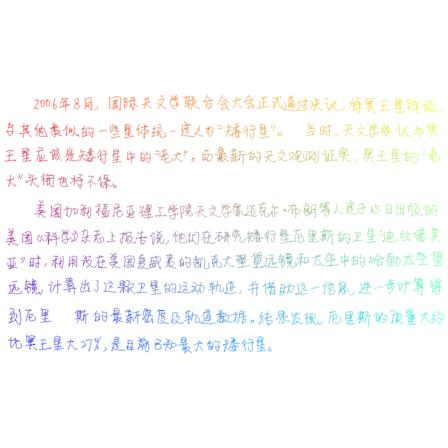
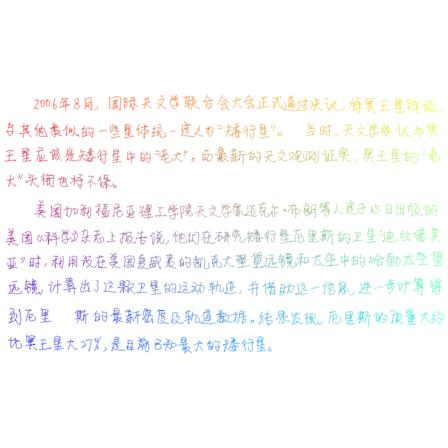

--------------------------------------------------
step: 1051/1636   lr: 0.00684   loss: 0.0037
step: 1052/1636   lr: 0.00682   loss: 0.0693
step: 1053/1636   lr: 0.00680   loss: 0.8098
step: 1054/1636   lr: 0.00678   loss: 1.2518
step: 1055/1636   lr: 0.00676   loss: 1.8928
step: 1056/1636   lr: 0.00674   loss: 0.0462
step: 1057/1636   lr: 0.00672   loss: 1.5891
step: 1058/1636   lr: 0.00670   loss: 0.8505
step: 1059/1636   lr: 0.00668   loss: 0.0975
step: 1060/1636   lr: 0.00666   loss: 0.1119
step: 1061/1636   lr: 0.00664   loss: 1.8187
step: 1062/1636   lr: 0.00662   loss: 0.0341
step: 1063/1636   lr: 0.00660   loss: 0.0100
step: 1064/1636   lr: 0.00658   loss: 0.0190
step: 1065/1636   lr: 0.00656   loss: 0.0144
step: 1066/1636   lr: 0.00654   loss: 0.0774
step: 1067/1636   lr: 0.00652   loss: 0.8438
step: 1068/1636   lr: 0.00650   loss: 0.1263
step: 1069/1636   lr: 0.00648   loss: 0.3961
step: 1070/1636   lr: 0.00646   loss: 0.1488
step: 1071/1636   lr: 0.00644   loss: 0.4451
step


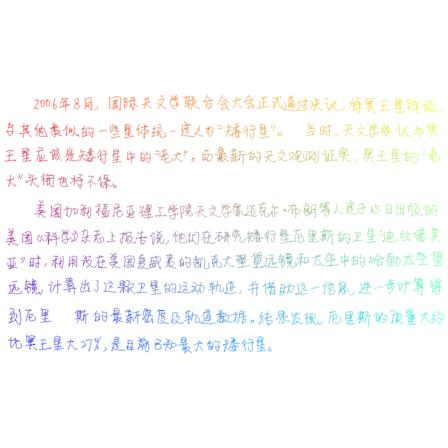
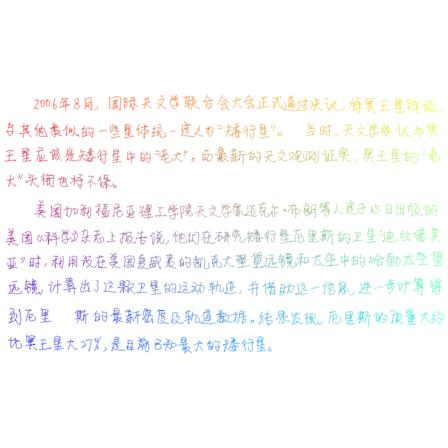

--------------------------------------------------
step: 1101/1636   lr: 0.00585   loss: 0.0482
step: 1102/1636   lr: 0.00583   loss: 0.8213
step: 1103/1636   lr: 0.00581   loss: 0.2181
step: 1104/1636   lr: 0.00579   loss: 0.0255
step: 1105/1636   lr: 0.00578   loss: 0.5651
step: 1106/1636   lr: 0.00576   loss: 0.0241
step: 1107/1636   lr: 0.00574   loss: 1.9444
step: 1108/1636   lr: 0.00572   loss: 1.7556
step: 1109/1636   lr: 0.00570   loss: 0.0088
step: 1110/1636   lr: 0.00568   loss: 0.1196
step: 1111/1636   lr: 0.00566   loss: 0.0117
step: 1112/1636   lr: 0.00564   loss: 0.0616
step: 1113/1636   lr: 0.00562   loss: 1.7210
step: 1114/1636   lr: 0.00560   loss: 0.0373
step: 1115/1636   lr: 0.00558   loss: 0.1364
step: 1116/1636   lr: 0.00556   loss: 0.1068
step: 1117/1636   lr: 0.00554   loss: 1.3430
step: 1118/1636   lr: 0.00553   loss: 0.0973
step: 1119/1636   lr: 0.00551   loss: 1.5508
step: 1120/1636   lr: 0.00549   loss: 1.8778
step: 1121/1636   lr: 0.00547   loss: 0.0121
step


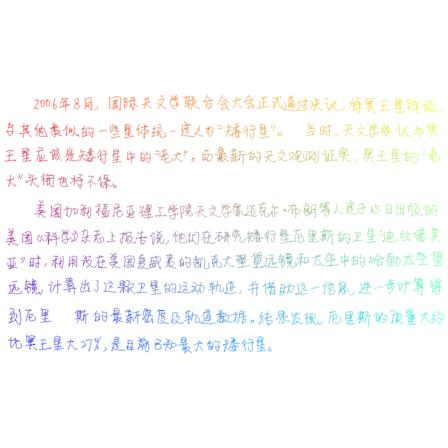
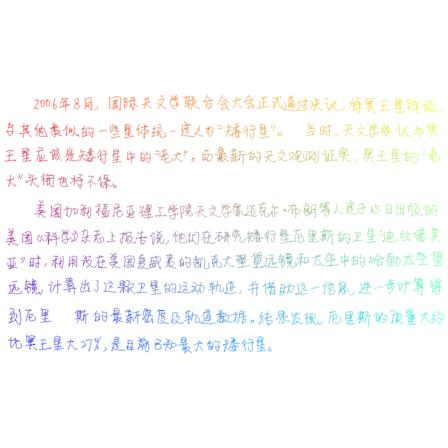

--------------------------------------------------
step: 1151/1636   lr: 0.00491   loss: 1.0658
step: 1152/1636   lr: 0.00489   loss: 0.6656
step: 1153/1636   lr: 0.00487   loss: 1.3584
step: 1154/1636   lr: 0.00485   loss: 0.0304
step: 1155/1636   lr: 0.00483   loss: 0.0370
step: 1156/1636   lr: 0.00482   loss: 0.0211
step: 1157/1636   lr: 0.00480   loss: 1.5466
step: 1158/1636   lr: 0.00478   loss: 0.0661
step: 1159/1636   lr: 0.00476   loss: 0.3727
step: 1160/1636   lr: 0.00474   loss: 0.0142
step: 1161/1636   lr: 0.00473   loss: 1.0686
step: 1162/1636   lr: 0.00471   loss: 0.0705
step: 1163/1636   lr: 0.00469   loss: 0.2254
step: 1164/1636   lr: 0.00467   loss: 0.4265
step: 1165/1636   lr: 0.00465   loss: 0.1775
step: 1166/1636   lr: 0.00464   loss: 0.1085
step: 1167/1636   lr: 0.00462   loss: 0.4096
step: 1168/1636   lr: 0.00460   loss: 0.0527
step: 1169/1636   lr: 0.00458   loss: 0.0138
step: 1170/1636   lr: 0.00456   loss: 0.4828
step: 1171/1636   lr: 0.00455   loss: 0.5631
step


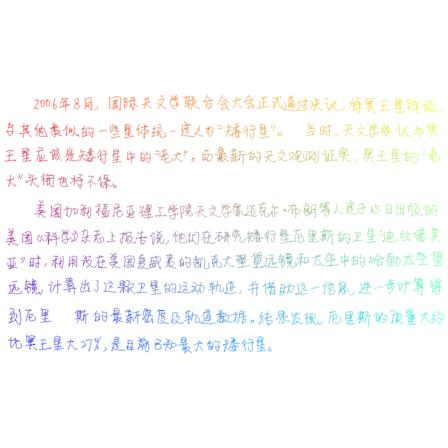
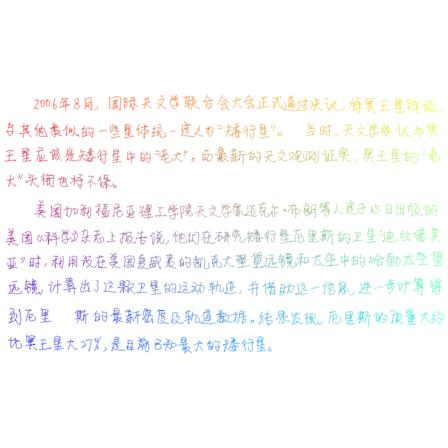

--------------------------------------------------
step: 1201/1636   lr: 0.00402   loss: 0.3202
step: 1202/1636   lr: 0.00400   loss: 0.3759
step: 1203/1636   lr: 0.00399   loss: 0.0482
step: 1204/1636   lr: 0.00397   loss: 0.0955
step: 1205/1636   lr: 0.00395   loss: 0.0294
step: 1206/1636   lr: 0.00394   loss: 0.4861
step: 1207/1636   lr: 0.00392   loss: 0.1254
step: 1208/1636   lr: 0.00390   loss: 0.0162
step: 1209/1636   lr: 0.00388   loss: 0.0707
step: 1210/1636   lr: 0.00387   loss: 1.4688
step: 1211/1636   lr: 0.00385   loss: 0.6706
step: 1212/1636   lr: 0.00383   loss: 2.4123
step: 1213/1636   lr: 0.00382   loss: 1.3158
step: 1214/1636   lr: 0.00380   loss: 0.0131
step: 1215/1636   lr: 0.00378   loss: 0.1415
step: 1216/1636   lr: 0.00377   loss: 1.5957
step: 1217/1636   lr: 0.00375   loss: 0.0526
step: 1218/1636   lr: 0.00373   loss: 0.0274
step: 1219/1636   lr: 0.00372   loss: 0.5235
step: 1220/1636   lr: 0.00370   loss: 0.5891
step: 1221/1636   lr: 0.00368   loss: 0.1551
step


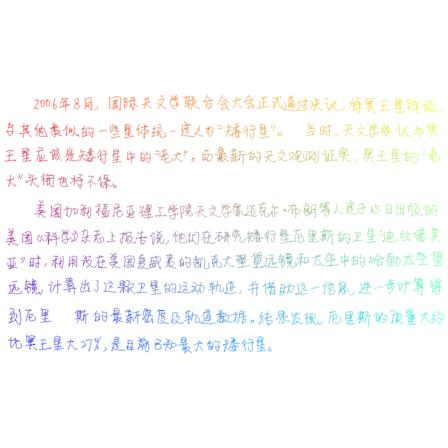
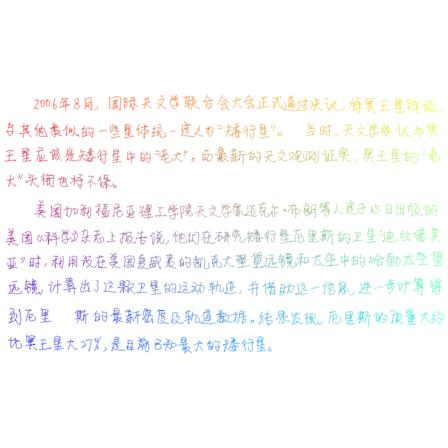

--------------------------------------------------
step: 1251/1636   lr: 0.00320   loss: 1.4851
step: 1252/1636   lr: 0.00319   loss: 0.0873
step: 1253/1636   lr: 0.00317   loss: 0.2840
step: 1254/1636   lr: 0.00315   loss: 0.0435
step: 1255/1636   lr: 0.00314   loss: 0.0663
step: 1256/1636   lr: 0.00312   loss: 2.7328
step: 1257/1636   lr: 0.00311   loss: 0.1625
step: 1258/1636   lr: 0.00309   loss: 0.0198
step: 1259/1636   lr: 0.00308   loss: 0.0359
step: 1260/1636   lr: 0.00306   loss: 0.0311
step: 1261/1636   lr: 0.00305   loss: 0.8554
step: 1262/1636   lr: 0.00303   loss: 1.3084
step: 1263/1636   lr: 0.00302   loss: 0.2225
step: 1264/1636   lr: 0.00300   loss: 0.8277
step: 1265/1636   lr: 0.00299   loss: 0.0167
step: 1266/1636   lr: 0.00297   loss: 0.0094
step: 1267/1636   lr: 0.00296   loss: 0.0080
step: 1268/1636   lr: 0.00294   loss: 0.3967
step: 1269/1636   lr: 0.00293   loss: 0.0637
step: 1270/1636   lr: 0.00291   loss: 0.0875
step: 1271/1636   lr: 0.00290   loss: 0.8451
step


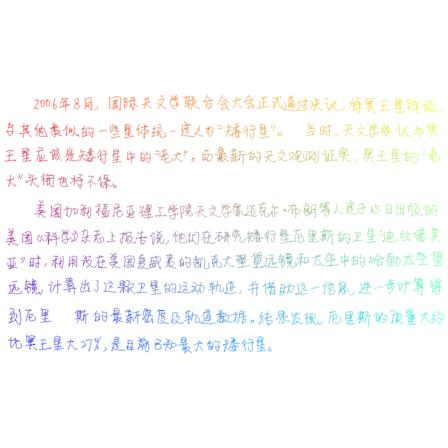
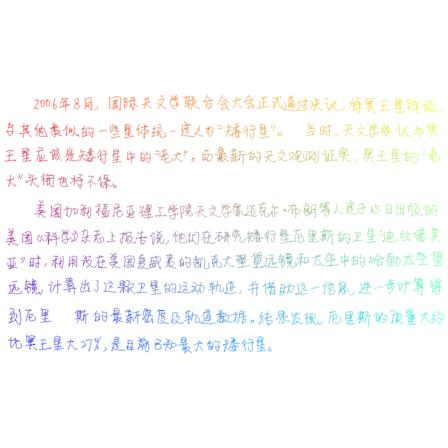

--------------------------------------------------
step: 1301/1636   lr: 0.00246   loss: 0.6469
step: 1302/1636   lr: 0.00245   loss: 1.1554
step: 1303/1636   lr: 0.00243   loss: 0.2570
step: 1304/1636   lr: 0.00242   loss: 1.8051
step: 1305/1636   lr: 0.00240   loss: 1.3388
step: 1306/1636   lr: 0.00239   loss: 1.0807
step: 1307/1636   lr: 0.00238   loss: 0.0302
step: 1308/1636   lr: 0.00236   loss: 0.0903
step: 1309/1636   lr: 0.00235   loss: 0.8050
step: 1310/1636   lr: 0.00233   loss: 0.9193
step: 1311/1636   lr: 0.00232   loss: 0.6316
step: 1312/1636   lr: 0.00231   loss: 0.0398
step: 1313/1636   lr: 0.00229   loss: 0.0897
step: 1314/1636   lr: 0.00228   loss: 0.0403
step: 1315/1636   lr: 0.00227   loss: 0.0305
step: 1316/1636   lr: 0.00225   loss: 0.1062
step: 1317/1636   lr: 0.00224   loss: 0.2088
step: 1318/1636   lr: 0.00223   loss: 0.2598
step: 1319/1636   lr: 0.00221   loss: 0.9128
step: 1320/1636   lr: 0.00220   loss: 0.1458
step: 1321/1636   lr: 0.00219   loss: 0.0769
step


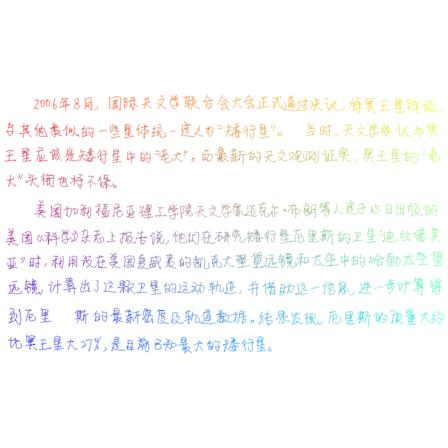
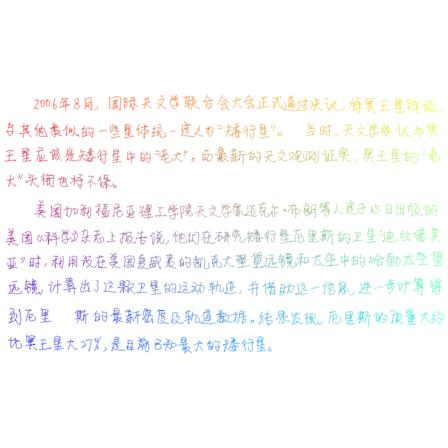

--------------------------------------------------
step: 1351/1636   lr: 0.00180   loss: 0.2450
step: 1352/1636   lr: 0.00179   loss: 0.9506
step: 1353/1636   lr: 0.00178   loss: 1.2355
step: 1354/1636   lr: 0.00177   loss: 2.0600
step: 1355/1636   lr: 0.00175   loss: 0.5972
step: 1356/1636   lr: 0.00174   loss: 0.0154
step: 1357/1636   lr: 0.00173   loss: 1.3433
step: 1358/1636   lr: 0.00172   loss: 0.1412
step: 1359/1636   lr: 0.00171   loss: 0.0364
step: 1360/1636   lr: 0.00169   loss: 0.0118
step: 1361/1636   lr: 0.00168   loss: 0.5966
step: 1362/1636   lr: 0.00167   loss: 1.4036
step: 1363/1636   lr: 0.00166   loss: 0.0864
step: 1364/1636   lr: 0.00165   loss: 0.7135
step: 1365/1636   lr: 0.00164   loss: 0.0673
step: 1366/1636   lr: 0.00162   loss: 0.0780
step: 1367/1636   lr: 0.00161   loss: 0.2993
step: 1368/1636   lr: 0.00160   loss: 0.9736
step: 1369/1636   lr: 0.00159   loss: 0.0121
step: 1370/1636   lr: 0.00158   loss: 0.0221
step: 1371/1636   lr: 0.00157   loss: 1.0076
step


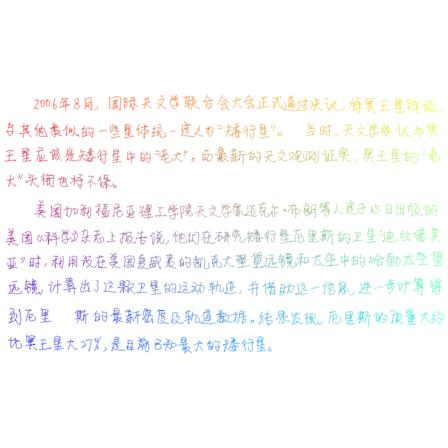
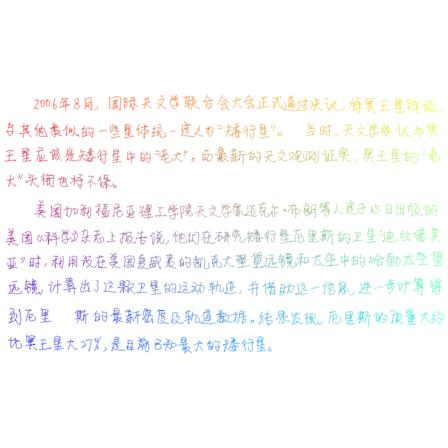

--------------------------------------------------
step: 1401/1636   lr: 0.00124   loss: 0.6474
step: 1402/1636   lr: 0.00123   loss: 0.3887
step: 1403/1636   lr: 0.00122   loss: 0.0099
step: 1404/1636   lr: 0.00121   loss: 1.3513
step: 1405/1636   lr: 0.00120   loss: 1.1252
step: 1406/1636   lr: 0.00119   loss: 1.3294
step: 1407/1636   lr: 0.00118   loss: 0.5194
step: 1408/1636   lr: 0.00117   loss: 0.6806
step: 1409/1636   lr: 0.00116   loss: 0.9493
step: 1410/1636   lr: 0.00115   loss: 0.0726
step: 1411/1636   lr: 0.00114   loss: 0.0298
step: 1412/1636   lr: 0.00113   loss: 1.0439
step: 1413/1636   lr: 0.00112   loss: 0.1371
step: 1414/1636   lr: 0.00111   loss: 0.3233
step: 1415/1636   lr: 0.00110   loss: 0.2612
step: 1416/1636   lr: 0.00109   loss: 0.0849
step: 1417/1636   lr: 0.00108   loss: 0.9107
step: 1418/1636   lr: 0.00107   loss: 0.4461
step: 1419/1636   lr: 0.00106   loss: 2.3428
step: 1420/1636   lr: 0.00105   loss: 0.2575
step: 1421/1636   lr: 0.00104   loss: 1.7186
step


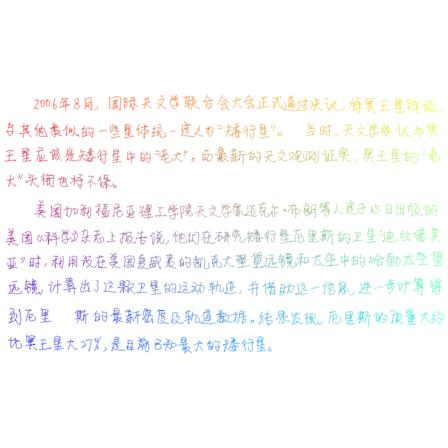
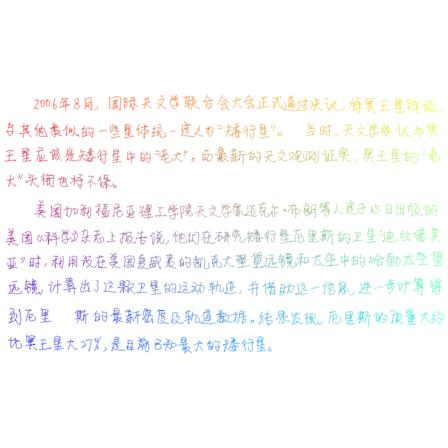

--------------------------------------------------
step: 1451/1636   lr: 0.00078   loss: 0.7167
step: 1452/1636   lr: 0.00077   loss: 0.3717
step: 1453/1636   lr: 0.00076   loss: 0.0699
step: 1454/1636   lr: 0.00075   loss: 0.0476
step: 1455/1636   lr: 0.00074   loss: 0.5624
step: 1456/1636   lr: 0.00074   loss: 0.0073
step: 1457/1636   lr: 0.00073   loss: 0.5254
step: 1458/1636   lr: 0.00072   loss: 0.2435
step: 1459/1636   lr: 0.00071   loss: 0.5454
step: 1460/1636   lr: 0.00070   loss: 0.2717
step: 1461/1636   lr: 0.00070   loss: 0.0368
step: 1462/1636   lr: 0.00069   loss: 1.8898
step: 1463/1636   lr: 0.00068   loss: 0.9609
step: 1464/1636   lr: 0.00067   loss: 0.1782
step: 1465/1636   lr: 0.00067   loss: 0.0050
step: 1466/1636   lr: 0.00066   loss: 0.0111
step: 1467/1636   lr: 0.00065   loss: 1.1408
step: 1468/1636   lr: 0.00064   loss: 0.0267
step: 1469/1636   lr: 0.00064   loss: 1.3083
step: 1470/1636   lr: 0.00063   loss: 0.2738
step: 1471/1636   lr: 0.00062   loss: 0.0664
step


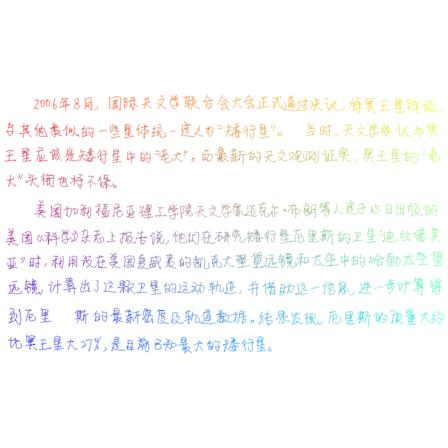
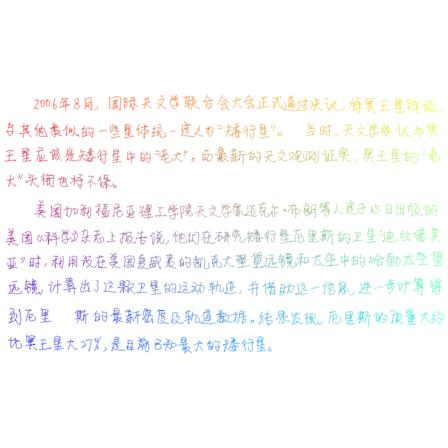

--------------------------------------------------
step: 1501/1636   lr: 0.00042   loss: 0.1510
step: 1502/1636   lr: 0.00041   loss: 0.4801
step: 1503/1636   lr: 0.00041   loss: 0.0928
step: 1504/1636   lr: 0.00040   loss: 1.2492
step: 1505/1636   lr: 0.00039   loss: 0.5715
step: 1506/1636   lr: 0.00039   loss: 0.6081
step: 1507/1636   lr: 0.00038   loss: 0.3828
step: 1508/1636   lr: 0.00038   loss: 0.9441
step: 1509/1636   lr: 0.00037   loss: 0.1014
step: 1510/1636   lr: 0.00036   loss: 1.4595
step: 1511/1636   lr: 0.00036   loss: 0.0482
step: 1512/1636   lr: 0.00035   loss: 0.0540
step: 1513/1636   lr: 0.00035   loss: 0.6333
step: 1514/1636   lr: 0.00034   loss: 1.2935
step: 1515/1636   lr: 0.00034   loss: 0.3716
step: 1516/1636   lr: 0.00033   loss: 0.2634
step: 1517/1636   lr: 0.00033   loss: 0.0039
step: 1518/1636   lr: 0.00032   loss: 0.0695
step: 1519/1636   lr: 0.00032   loss: 0.0131
step: 1520/1636   lr: 0.00031   loss: 0.5756
step: 1521/1636   lr: 0.00030   loss: 0.0275
step


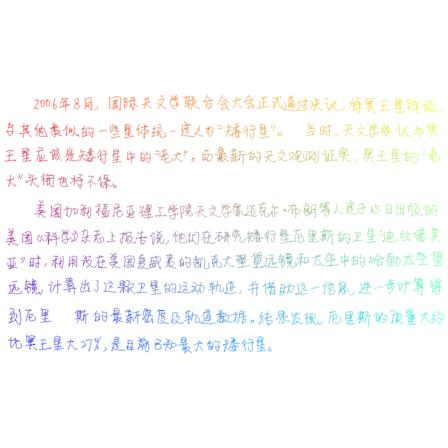
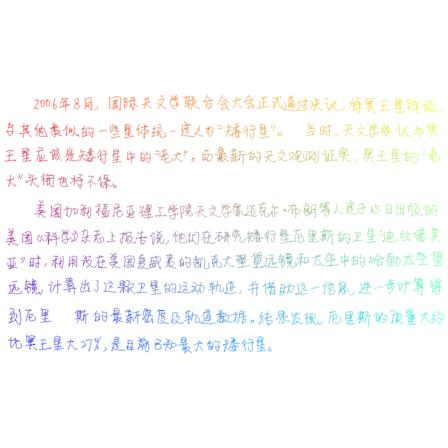

--------------------------------------------------
step: 1551/1636   lr: 0.00017   loss: 0.8775
step: 1552/1636   lr: 0.00016   loss: 0.9059
step: 1553/1636   lr: 0.00016   loss: 0.0402
step: 1554/1636   lr: 0.00016   loss: 0.0349
step: 1555/1636   lr: 0.00015   loss: 0.0489
step: 1556/1636   lr: 0.00015   loss: 0.1138
step: 1557/1636   lr: 0.00015   loss: 1.2664
step: 1558/1636   lr: 0.00014   loss: 0.8959
step: 1559/1636   lr: 0.00014   loss: 1.5874
step: 1560/1636   lr: 0.00013   loss: 1.1068
step: 1561/1636   lr: 0.00013   loss: 0.5044
step: 1562/1636   lr: 0.00013   loss: 0.1172
step: 1563/1636   lr: 0.00012   loss: 0.7665
step: 1564/1636   lr: 0.00012   loss: 1.1149
step: 1565/1636   lr: 0.00012   loss: 0.4835
step: 1566/1636   lr: 0.00011   loss: 0.0933
step: 1567/1636   lr: 0.00011   loss: 0.1358
step: 1568/1636   lr: 0.00011   loss: 1.2174
step: 1569/1636   lr: 0.00010   loss: 0.9546
step: 1570/1636   lr: 0.00010   loss: 0.0032
step: 1571/1636   lr: 0.00010   loss: 0.7531
step


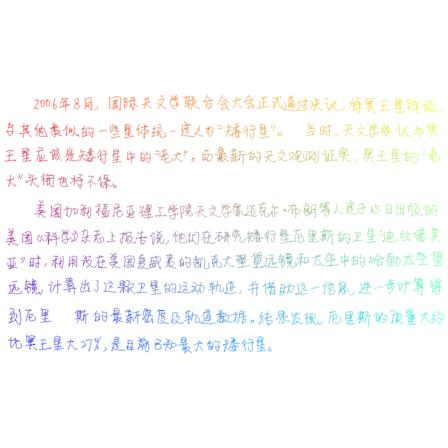
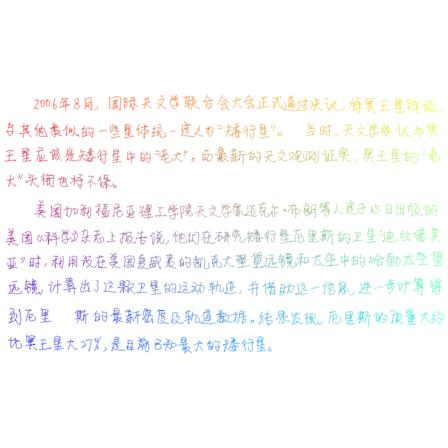

--------------------------------------------------
step: 1601/1636   lr: 0.00003   loss: 1.6855
step: 1602/1636   lr: 0.00003   loss: 0.0041
step: 1603/1636   lr: 0.00003   loss: 0.0342
step: 1604/1636   lr: 0.00002   loss: 0.0801
step: 1605/1636   lr: 0.00002   loss: 0.8142
step: 1606/1636   lr: 0.00002   loss: 0.5708
step: 1607/1636   lr: 0.00002   loss: 0.2259
step: 1608/1636   lr: 0.00002   loss: 1.5691
step: 1609/1636   lr: 0.00002   loss: 0.1620
step: 1610/1636   lr: 0.00002   loss: 0.7274
step: 1611/1636   lr: 0.00002   loss: 0.1471
step: 1612/1636   lr: 0.00001   loss: 0.0770
step: 1613/1636   lr: 0.00001   loss: 0.0848
step: 1614/1636   lr: 0.00001   loss: 0.0107
step: 1615/1636   lr: 0.00001   loss: 0.0141
step: 1616/1636   lr: 0.00001   loss: 1.1073
step: 1617/1636   lr: 0.00001   loss: 0.4842
step: 1618/1636   lr: 0.00001   loss: 1.5899
step: 1619/1636   lr: 0.00001   loss: 1.2447
step: 1620/1636   lr: 0.00001   loss: 0.0931
step: 1621/1636   lr: 0.00001   loss: 0.3117
step

In [23]:
# --- 使用训练集进行微调 ---

# 定义超参数
BATCH_SIZE = 1  # 由于使用896px和长序列，建议减小批大小以防显存溢出
TRAIN_STEPS = 1636 # 训练步数，您可以根据需要调整。例如，训练一个完整的epoch所需的步数 = 总图片数 / BATCH_SIZE
LEARNING_RATE = 0.02 # 学习率，可以从0.01或0.005开始尝试
EVAL_STEPS = 50   # 每训练50步，进行一次评估

# 使用我们新创建的训练数据迭代器
train_data_it = train_data_iterator()

# 使用我们之前为测试集创建的迭代器进行验证
validation_data_it = data_htr_test_iterator 

# 创建学习率调度器
sched_fn = big_vision.utils.create_learning_rate_schedule(
    total_steps=TRAIN_STEPS + 1, base=LEARNING_RATE,
    decay_type="cosine", warmup_percent=0.10)

# 开始训练循环
for step in range(1, TRAIN_STEPS + 1):
  # 构造一个批次的数据
  examples = [next(train_data_it) for _ in range(BATCH_SIZE)]
  batch = jax.tree.map(lambda *x: np.stack(x), *examples)
  batch = big_vision.utils.reshard(batch, data_sharding)

  # 执行一个训练步
  learning_rate = sched_fn(step)
  params, loss = update_fn(params, batch, learning_rate)

  loss = jax.device_get(loss)
  print(f"step: {step:3d}/{TRAIN_STEPS:3d}   lr: {learning_rate:.5f}   loss: {loss:.4f}")

  # 每隔 EVAL_STEPS 步，在验证集上进行一次预测并展示结果
  if (step % EVAL_STEPS) == 0:
    print(f"\n--- 模型在第 {step} 步的预测表现 ---")
    html_out = ""
    # 注意这里调用的是 validation_data_it()，即 your_data_ocr_test_iterator
    for _ in range(2): # 展示2个验证样本
        try:
            example_data, ground_truth_str = next(validation_data_it())
            example_data['_mask'] = np.array(True)
            val_batch = jax.tree.map(lambda x: np.expand_dims(x, axis=0), example_data)
            val_batch = big_vision.utils.reshard(val_batch, data_sharding)
            tokens = decode({"params": params}, batch=val_batch, max_decode_len=SEQLEN, sampler="greedy")
            tokens = jax.device_get(tokens)
            response = postprocess_tokens(tokens[0])
            html_out += render_ocr_example(example_data["image"], ground_truth_str, response)
        except StopIteration:
            break
    display(HTML(html_out))
    print("-" * 50)

## 输出结果

运行下方代码，对验证集的图片进行手写文字识别。


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
成功加载用于最终评估的测试数据集。
--- 正在评估微调后模型的表现 ---



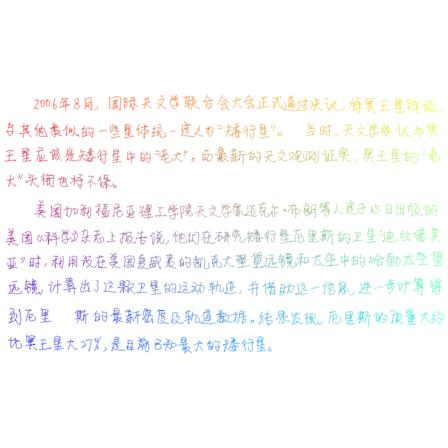
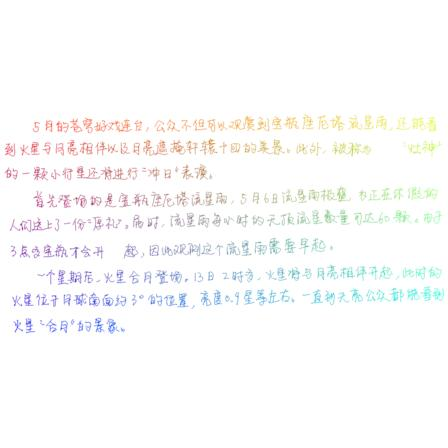
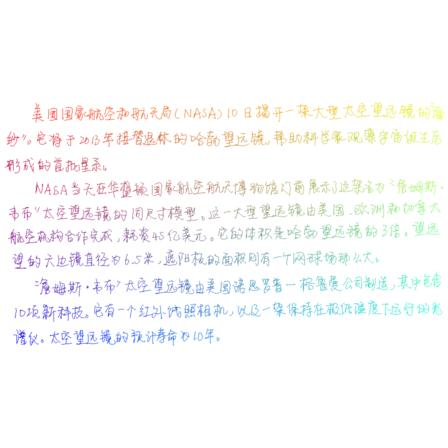
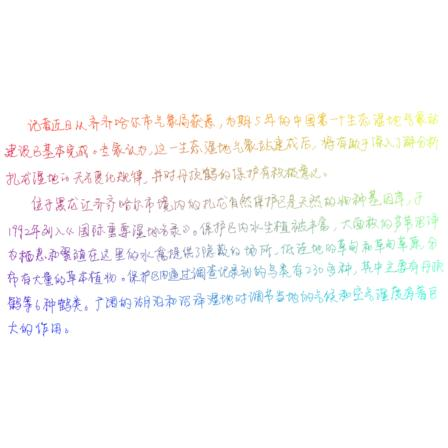
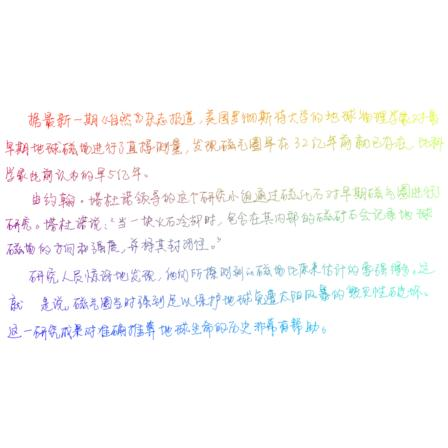
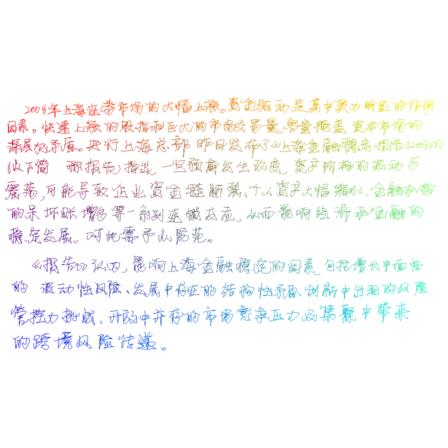
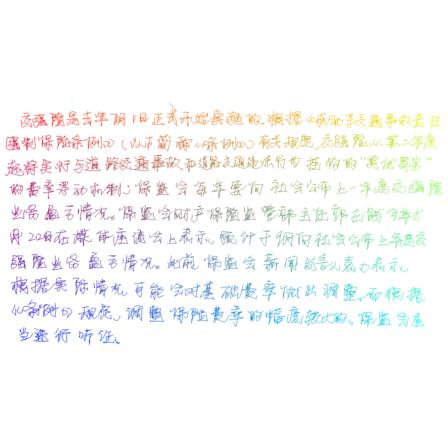
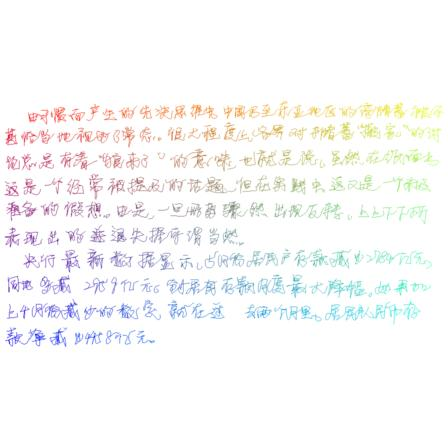
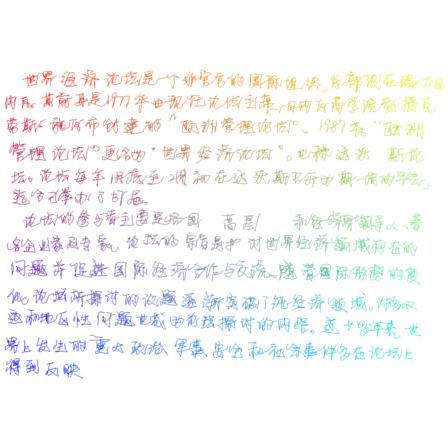
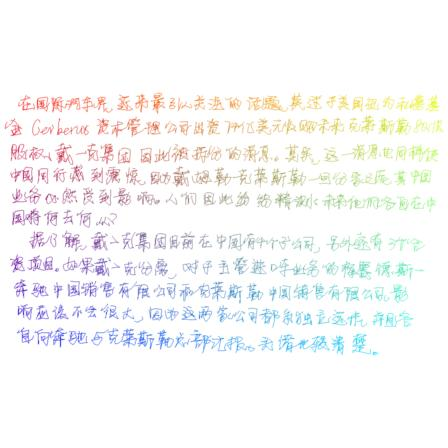

In [24]:
# --- 使用微调后的模型在测试集上进行最终评估 ---

# 1. 定义测试数据路径
YOUR_IMAGE_DIR = "/kaggle/input/encoded-images/encoded_dataset/WPTT2.0-Test"
YOUR_JSONL_FILE_PATH = "/kaggle/working/WPTT2.0-Test.jsonl" 

# 2. 加载测试数据源 
try:
    your_custom_dataset = big_vision.datasets.jsonl.DataSource(
        YOUR_JSONL_FILE_PATH,
        fopen_keys={"image": YOUR_IMAGE_DIR}
    )
    print("成功加载用于最终评估的测试数据集。")
except Exception as e:
    print(f"加载测试数据集时出错: {e}")
    your_custom_dataset = None

# 3. 创建测试数据迭代器 (无需修改)
def data_htr_test_iterator():
  for example in your_custom_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = tf.image.decode_image(example["image"], channels=3).numpy()
    image = preprocess_image(image) # 这里会自动使用您修改后的 size=448
    prefix = "handwriting recognition"
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)

    jax_batch_data = {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }
    ground_truth_text = example["suffix"].decode('utf-8')
    yield jax_batch_data, ground_truth_text

# 4. 调用预测函数并展示最终结果
if your_custom_dataset:
    print("--- 正在评估微调后模型的表现 ---")
    html_out_final = ""

    # 渲染函数 (无需修改)
    def render_ocr_example(image, ground_truth, model_prediction):
      image = ((image + 1)/2 * 255).astype(np.uint8)
      return f"""
        <div style="display: flex; align-items: start; border: 1px solid #ccc; margin-bottom: 10px; padding: 5px;">
            <img style="width:128px; height:128px; margin-right: 10px;" src="{render_inline(image, resize=(128,128))}" />
            <div style="display: flex; flex-direction: column; max-width: 600px;">
                <p style="margin: 0; word-wrap: break-word;"><b>真实文本 (Ground Truth):</b><br>{html.escape(ground_truth)}</p>
                <hr style="width:100%; margin: 5px 0;">
                <p style="margin: 0; word-wrap: break-word;"><b>模型识别 (Prediction):</b><br>{html.escape(model_prediction)}</p>
            </div>
        </div>
        """

    iterator = your_data_ocr_test_iterator()
    # 评估测试集中的前10张图片
    for _ in range(10): 
        try:
            example_data, ground_truth_str = next(iterator)
            example_data['_mask'] = np.array(True)
            batch = jax.tree.map(lambda x: np.expand_dims(x, axis=0), example_data)
            batch = big_vision.utils.reshard(batch, data_sharding)
            
            # 使用已更新的 params 进行预测
            tokens = decode({"params": params}, batch=batch, max_decode_len=SEQLEN, sampler="greedy")
            
            tokens = jax.device_get(tokens)
            response = postprocess_tokens(tokens[0])
            
            html_out_final += render_ocr_example(example_data["image"], ground_truth_str, response)

        except StopIteration:
            print("已评估完所有可用的测试数据。")
            break

    display(HTML(html_out_final))

### 保存权重

In [29]:
flat, _ = big_vision.utils.tree_flatten_with_names(params)
with open("ckpt.npz", "wb") as f:
  np.savez(f, **{k: v for k, v in flat})

{'img': {'pos_embedding': array([[[-0.05737, -0.2256 , -0.0957 , ...,  0.0791 ,  1.023  ,
           -0.25   ],
          [-0.05762, -0.2021 , -0.06396, ...,  0.0884 ,  0.742  ,
           -0.2598 ],
          [-0.0564 , -0.1738 , -0.03064, ...,  0.09766,  0.457  ,
           -0.2734 ],
          ...,
          [-0.0515 , -0.1514 , -0.02698, ...,  0.1079 , -0.2031 ,
           -0.252  ],
          [-0.06104, -0.1465 , -0.05225, ...,  0.104  , -0.547  ,
           -0.2715 ],
          [-0.0718 , -0.1377 , -0.08154, ...,  0.10156, -0.8867 ,
           -0.293  ]]], dtype=float16),
  'Transformer': {'encoder_norm': {'bias': array([0.3633 , 0.3047 , 0.1816 , ..., 0.03857, 0.2578 , 0.0703 ],
          dtype=float16),
    'scale': array([1.625, 1.43 , 1.594, ..., 1.602, 1.703, 1.414], dtype=float16)},
   'encoderblock': {'LayerNorm_0': {'bias': array([[-1.6098e-03,  9.5367e-04,  1.2878e-02, ..., -1.6113e-02,
              3.0273e-02, -1.8768e-03],
            [-3.2471e-02, -3.5553e-03,  2.655